# SAM MSL Autoencoder: Analysis Notebook

Complete post-training analysis for the Southern Annular Mode (SAM) mean
sea-level pressure convolutional autoencoders. The notebook is organised in
three parts that must be run in order:

| Part | Description |
|---|---|
| **Part 1** | Full-year autoencoder — reconstruction quality, elbow analysis, cluster visualisation |
| **Part 2** | Seasonal autoencoders — per-season hierarchical clustering and composite maps |
| **Part 3** | Time series and comparison — SAM index construction, EOF comparison, Marshall AAO validation |

**Required inputs** (produced by the training scripts):
- `$SCRATCH/sam_preprocessed_data.nc` — from `run_preprocess_msl.py`
- `$SCRATCH/sam_pca_data.nc` — from `run_pca.py`
- `$SCRATCH/autoencoder_models/<TAG>.*` — from `run_autoencoder.py`
- `$SCRATCH/autoencoder_models/<SEASON_TAG>.*` — from `run_seasonal_autoencoder.py` (×4)

**Outputs**: figures saved to `figures/`; `$SCRATCH/ae_cluster_data.nc` (end of Part 1)

> **Paper**: Posternack & Koepnick, "Identifying Regime Structure of the Southern
> Annular Mode using Clustering Autoencoder Techniques", *JGR: Machine Learning
> and Computation* (in review).
>
> Run all cells top-to-bottom. Part 1 → Part 2 → Part 3; each part depends on
> outputs from the previous.


## Imports

In [1]:
import os
import re
import gc
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import dask

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import matplotlib.ticker as mticker
import matplotlib.path as mpath
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from tensorflow import keras

warnings.filterwarnings('ignore')
import urllib.request


ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/apps/opt/conda/envs/npl-2025a/share/proj failed
2026-04-13 18:32:53.225634: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-13 18:32:53.337179: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-13 18:32:53.371478: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776126773.410995  105289 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776126773.424515  105289 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776126773.503376  105

## Configuration

Update the paths and tags below to match your run.


In [2]:
SCRATCH  = os.path.expandvars('/glade/derecho/scratch/$USER')
SAVE_DIR = os.path.join(SCRATCH, 'autoencoder_models')
OUT_DIR  = SCRATCH

# Tag used when running run_autoencoder.py
TAG = 'sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped'

# Tags used when running run_seasonal_autoencoder.py
SEASON_TAGS = {
    'DJF': 'sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped_lintrend_DJF',
    'MAM': 'sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped_lintrend_MAM',
    'JJA': 'sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped_lintrend_JJA',
    'SON': 'sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped_lintrend_SON',
}


## Shared helper functions

Polar map plotting, cluster data builder, and cluster summary plotter.
Defined once here; used by both Part 1 and Part 2.


In [3]:
def _polar_map(ax, lons, lats, img, title, cmap='bwr', label='MSL (std)',
               vmax=None, vmin=None, add_colorbar=True):
    import matplotlib.path as mpath
    pc = ccrs.PlateCarree()
    edge_lat = float(np.max(lats))
    theta  = np.linspace(0, 2 * np.pi, 200)
    lons_b = np.rad2deg(theta) % 360
    lons_b[lons_b > 180] -= 360
    lats_b = np.full(200, edge_lat)
    pts_b  = ax.projection.transform_points(pc, lons_b, lats_b)
    R      = np.sqrt(pts_b[:, 0] ** 2 + pts_b[:, 1] ** 2).max()
    ax.set_extent([-R, R, -R, R], crs=ax.projection)
    circle = mpath.Path(pts_b[:, :2])
    ax.set_boundary(circle, transform=ax.projection)
    img = np.nan_to_num(img, nan=0.0)
    if vmax is None:
        vmax = np.percentile(np.abs(img), 85)
    if vmax < 0.0001:
        vmax = 0.0001
    _vmin  = -vmax if vmin is None else vmin
    levels = np.linspace(_vmin, vmax, 17)
    img_c, lons_c = add_cyclic_point(img, coord=lons)
    cf = ax.contourf(lons_c, lats, img_c, levels=levels, transform=pc,
                     cmap=cmap, extend='both')
    pos_levels = levels[levels > 0]
    neg_levels = levels[levels < 0]
    contour_kw = dict(transform=pc, colors='black', linewidths=1.5, alpha=0.7)
    if len(pos_levels):
        ax.contour(lons_c, lats, img_c, levels=pos_levels, linestyles='solid',  **contour_kw)
    if len(neg_levels):
        ax.contour(lons_c, lats, img_c, levels=neg_levels, linestyles='dashed', **contour_kw)
    ax.coastlines(linewidth=1.0, color='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.2)
    gl = ax.gridlines(crs=pc, draw_labels=False,
                      linewidth=0.7, color='gray', alpha=0.5, linestyle='--')
    gl.xlocator = mticker.FixedLocator(range(-180, 181, 30))
    gl.ylocator = mticker.FixedLocator([-80, -70, -60, -50, -40, -30])
    lon_labels = {
        -150: '150°W', -120: '120°W', -90: '90°W',
        -60:  '60°W',  -30:  '30°W',
         30:  '30°E',   60:  '60°E',  90: '90°E',
        120:  '120°E', 150:  '150°E',
    }
    center = np.array([0.5, 0.5])
    for lon_val, lbl in lon_labels.items():
        xy_data = ax.projection.transform_point(lon_val, -20., pc)
        if not np.all(np.isfinite(xy_data)):
            continue
        xy_disp   = ax.transData.transform(xy_data)
        xy_ax     = ax.transAxes.inverted().transform(xy_disp)
        direction = xy_ax - center
        norm_d    = np.linalg.norm(direction)
        if norm_d < 1e-6:
            continue
        label_pos = center + (direction / norm_d) * 0.585
        ax.text(*label_pos, lbl, transform=ax.transAxes,
                ha='center', va='center', fontsize=25, color='dimgray',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    if add_colorbar:
        cbar = plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.05, shrink=0.8, aspect=25)
        cbar.set_ticks(np.linspace(_vmin, vmax, 5))
        cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        cbar.ax.tick_params(labelsize=30)
        cbar.set_label(label, fontsize=40, fontweight='bold')
    ax.set_title(title, fontsize=40, fontweight='bold', pad=60)
    return cf, vmax


def _coarsen_img(img, factor):
    if factor <= 1:
        return img
    h, w = img.shape
    h2   = (h // factor) * factor
    w2   = (w // factor) * factor
    return img[:h2, :w2].reshape(h2 // factor, factor, w2 // factor, factor).mean(axis=(1, 3))


def build_cluster_data(encoded_imgs, x_original_data, event_lats_padded, event_lons_padded,
                       k=4, top_n=None, max_instances_per_cluster=10, avg_coarsen=4,
                       linkage_method='ward'):
    latent_vectors = encoded_imgs.reshape((encoded_imgs.shape[0], -1))
    latent_vectors = StandardScaler().fit_transform(latent_vectors)
    Z              = linkage(latent_vectors, method=linkage_method)
    cluster_labels = fcluster(Z, k, criterion='maxclust') - 1
    total_events   = len(cluster_labels)
    print(f"Clustering {total_events} events into {k} clusters "
          f"(hierarchical, method='{linkage_method}')...")
    cluster_data = []
    for cluster_id in range(k):
        indices       = np.where(cluster_labels == cluster_id)[0]
        percent       = 100 * len(indices) / total_events
        original_imgs = [x_original_data[i, :, :, 0] for i in indices]
        avg_original  = np.mean([_coarsen_img(img, avg_coarsen) for img in original_imgs], axis=0)
        first_idx     = indices[0]
        avg_lons      = event_lons_padded[first_idx][::avg_coarsen][:avg_original.shape[1]]
        avg_lats      = event_lats_padded[first_idx][::avg_coarsen][:avg_original.shape[0]]
        entry = {
            'cluster_id': cluster_id, 'indices': indices,
            'indices_to_show': indices[:max_instances_per_cluster],
            'percent': percent, 'size': len(indices),
            'avg_original': avg_original, 'avg_lons': avg_lons, 'avg_lats': avg_lats,
            'original_imgs': original_imgs[:max_instances_per_cluster],
        }
        cluster_data.append(entry)
        print(f'  Cluster {cluster_id + 1}: {len(indices)} events ({percent:.1f}%)')
    cluster_data.sort(key=lambda x: x['percent'], reverse=True)
    if top_n is not None:
        cluster_data = cluster_data[:top_n]
    for rank, ci in enumerate(cluster_data):
        ci['cluster_id'] = rank
    return cluster_data, cluster_labels, Z


def plot_cluster_summary(cluster_data, title_prefix='', label='MSL (std)'):
    n_clusters = len(cluster_data)
    if n_clusters == 3:
        shared_vmax = max(
            np.percentile(np.abs(np.nan_to_num(ci['avg_original'], nan=0.0)), 85)
            for ci in cluster_data[:2])
        shared_vmax = max(shared_vmax, 0.0001)
        solo_vmax   = max(
            np.percentile(np.abs(np.nan_to_num(cluster_data[2]['avg_original'], nan=0.0)), 85),
            0.0001)
        fig = plt.figure(figsize=(9 * n_clusters, 11))
        shared_cf = solo_cf = None
        for col, ci in enumerate(cluster_data):
            ax   = fig.add_subplot(1, n_clusters, col + 1, projection=ccrs.SouthPolarStereo())
            vmax = shared_vmax if col < 2 else solo_vmax
            cf, _ = _polar_map(
                ax, ci['avg_lons'], ci['avg_lats'], ci['avg_original'],
                title=f'Cluster {ci["cluster_id"]+1}\n{ci["size"]} events ({ci["percent"]:.1f}%)',
                vmax=vmax, add_colorbar=False)
            ax.set_title(f'({chr(ord("a")+col)}) ' + ax.get_title(),
                         fontsize=40, fontweight='bold', pad=60)
            if col < 2: shared_cf = cf
            else:        solo_cf   = cf
        plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.11, wspace=0.55)
        cbar1 = fig.colorbar(shared_cf, cax=fig.add_axes([0.04, 0.08, 0.57, 0.05]),
                             orientation='horizontal')
        cbar1.set_ticks(np.linspace(-shared_vmax, shared_vmax, 5))
        cbar1.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        cbar1.ax.tick_params(labelsize=30)
        cbar1.set_label(label, fontsize=30, fontweight='bold')
        cbar2 = fig.colorbar(solo_cf, cax=fig.add_axes([0.76, 0.08, 0.20, 0.05]),
                             orientation='horizontal')
        cbar2.set_ticks(np.linspace(-solo_vmax, solo_vmax, 5))
        cbar2.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        cbar2.ax.tick_params(labelsize=30)
        cbar2.set_label(label, fontsize=30, fontweight='bold')
    else:
        global_vmax = max(
            np.percentile(np.abs(np.nan_to_num(ci['avg_original'], nan=0.0)), 85)
            for ci in cluster_data)
        global_vmax = max(global_vmax, 0.0001)
        fig = plt.figure(figsize=(9 * n_clusters, 11))
        last_cf = None
        for col, ci in enumerate(cluster_data):
            ax = fig.add_subplot(1, n_clusters, col+1, projection=ccrs.SouthPolarStereo())
            cf, _ = _polar_map(
                ax, ci['avg_lons'], ci['avg_lats'], ci['avg_original'],
                title=f'Cluster {ci["cluster_id"]+1}\n{ci["size"]} events ({ci["percent"]:.1f}%)',
                vmax=global_vmax, add_colorbar=False)
            ax.set_title(f'({chr(ord("a")+col)}) ' + ax.get_title(),
                         fontsize=40, fontweight='bold', pad=60)
            last_cf = cf
        plt.subplots_adjust(left=0.02, right=0.98, top=0.88, bottom=0.11, wspace=0.55)
        cbar = fig.colorbar(last_cf, cax=fig.add_axes([0.15, 0.08, 0.70, 0.022]),
                            orientation='horizontal')
        cbar.set_ticks(np.linspace(-global_vmax, global_vmax, 5))
        cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        cbar.ax.tick_params(labelsize=30)
        cbar.set_label(label, fontsize=28, fontweight='bold')
    save_dir = 'figures'
    plt.savefig(os.path.join(save_dir, 'composites.pdf'), dpi=300, bbox_inches='tight')
    plt.show()


---
# Part 1: Full-Year Autoencoder

Loads the full-year autoencoder trained on all monthly MSL data (1980–2022),
evaluates reconstruction quality, performs elbow analysis, and identifies
recurrent circulation clusters in the latent space.

**Paper reference**: Architecture and training described in Section 3.2
(Autoencoder Framework). Reconstruction performance is reported in Section 4
(Results) and shown in Supplementary Fig. S1 (`autoencoder_reconstruction.pdf`).


## 1.1 Load saved model and arrays

In [4]:
print(f"TAG               : {TAG}")
autoencoder       = keras.models.load_model(os.path.join(SAVE_DIR, f"autoencoder_{TAG}.keras"))
encoder           = keras.models.load_model(os.path.join(SAVE_DIR, f"encoder_{TAG}.keras"))
print(f"encoder           : {encoder}")
encoded_all       = np.load(os.path.join(SAVE_DIR, f"encoded_all_{TAG}.npy"))
print(f"encoded_all       : {encoded_all.shape}")
data_standardized = np.load(os.path.join(SAVE_DIR, f"data_standardized_{TAG}.npy"))
print(f"data_standardized : {data_standardized.shape}")
lats_coarse       = np.load(os.path.join(SAVE_DIR, f"lats_{TAG}.npy"))
lons_coarse       = np.load(os.path.join(SAVE_DIR, f"lons_{TAG}.npy"))
print(f"lats              : {lats_coarse.shape}  ({lats_coarse.min():.1f} to {lats_coarse.max():.1f})")
print(f"lons              : {lons_coarse.shape}  ({lons_coarse.min():.1f} to {lons_coarse.max():.1f})")
times             = np.load(os.path.join(SAVE_DIR, f"times_{TAG}.npy"), allow_pickle=True)
print(f"times             : {times.shape}")
n_samples, lat_length, lon_length, _ = data_standardized.shape
print(f"n_samples         : {n_samples}")
print(f"lat_length        : {lat_length}")
print(f"lon_length        : {lon_length}")


TAG               : sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped


2026-04-13 18:33:01.896187: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


encoder           : <Functional name=functional_1, built=True>
encoded_all       : (516, 9, 45, 4)
data_standardized : (516, 281, 1440, 1)
lats              : (281,)  (-90.0 to -20.0)
lons              : (1440,)  (0.0 to 359.8)
times             : (516,)
n_samples         : 516
lat_length        : 281
lon_length        : 1440


## 1.2 Train/test split

In [5]:
event_indices = np.arange(n_samples)
x_train, x_test, train_indices, test_indices = train_test_split(
    data_standardized, event_indices, test_size=0.2, random_state=5
)

centered_meta      = [{"time": t, "index": i} for i, t in enumerate(times)]
event_lats_padded  = [lats_coarse] * n_samples
event_lons_padded  = [lons_coarse] * n_samples

print(f"Train : {x_train.shape}  Test : {x_test.shape}")
print(f"Test indices (first 10): {test_indices[:10]}")

Train : (412, 281, 1440, 1)  Test : (104, 281, 1440, 1)
Test indices (first 10): [328 353 350 150 278  71 134 370 248  90]


# Architecture summary.
# Paper Section 3.2: encoder 5 × (Conv2D + MaxPool), decoder 5 × (Conv2D + UpSample) + Cropping2D.
# Latent shape (23, 45, 4) → compression factor 250.78× (0.4% of input).
## 1.3 Model summary stats

In [6]:
input_shape  = data_standardized.shape[1:]
latent_shape = encoded_all.shape[1:]
input_size   = int(np.prod(input_shape))
latent_size  = int(np.prod(latent_shape))
compression  = input_size / latent_size

print("=" * 48)
print(f"  Tag                  : {TAG}")
print("=" * 48)
print(f"  Input shape          : {input_shape}")
print(f"  Latent shape         : {latent_shape}")
print(f"  Input  size (pixels) : {input_size:,}")
print(f"  Latent size (values) : {latent_size:,}")
print(f"  Compression ratio    : {compression:.2f}x  ({100/compression:.1f}% of input)")
print("=" * 48)


  Tag                  : sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped
  Input shape          : (281, 1440, 1)
  Latent shape         : (9, 45, 4)
  Input  size (pixels) : 404,640
  Latent size (values) : 1,620
  Compression ratio    : 249.78x  (0.4% of input)


In [7]:
# Geographic bounds of this dataset
print(f"Latitude range : {float(lats_coarse.min()):.2f} to {float(lats_coarse.max()):.2f}")
print(f"Longitude range: {float(lons_coarse.min()):.2f} to {float(lons_coarse.max()):.2f}")
print(f"Grid size      : lat={lats_coarse.size}, lon={lons_coarse.size}")

Latitude range : -90.00 to -20.00
Longitude range: 0.00 to 359.75
Grid size      : lat=281, lon=1440


## 1.4 Original vs reconstructed (polar maps)

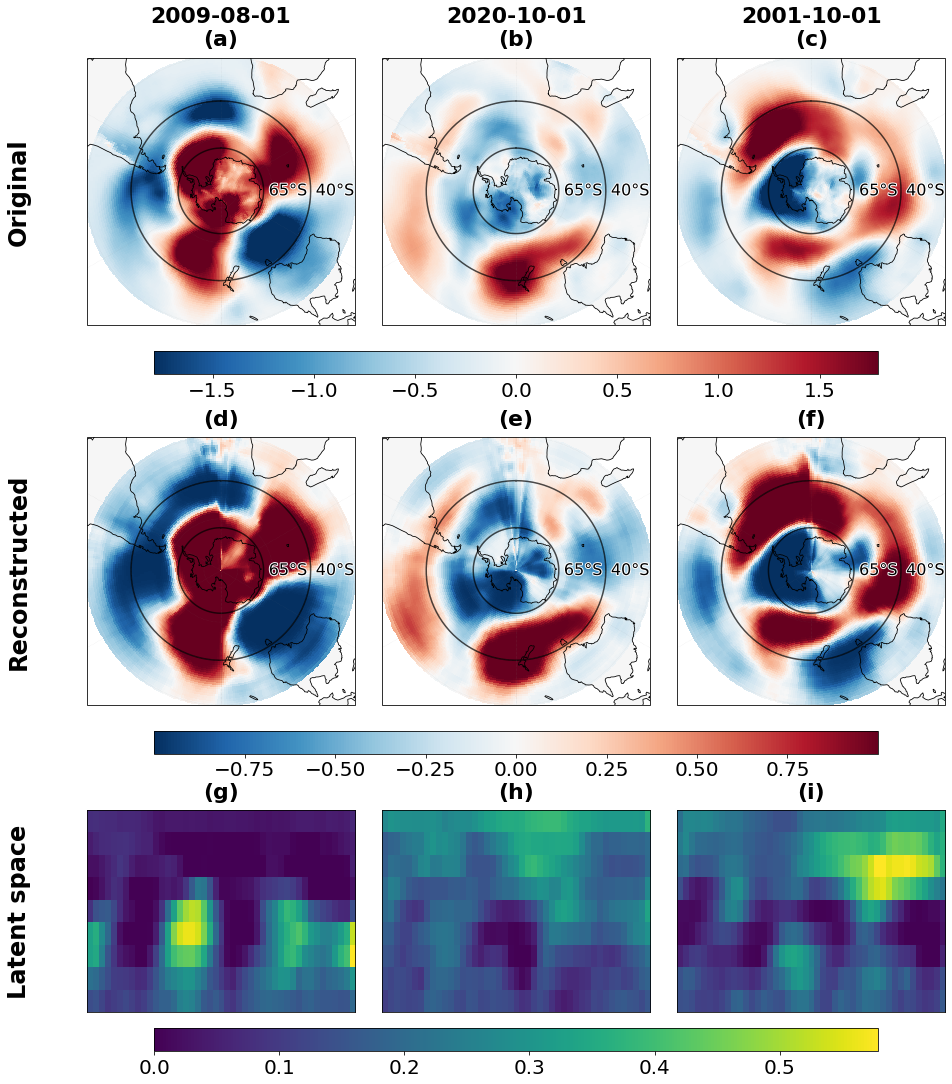

In [8]:
def inpaint_lon_seam(z, lons, seam_lon=0.0, half_width=1):
    z = np.array(z, dtype=float)
    d = np.abs((lons - seam_lon + 180) % 360 - 180)
    c, nlon = int(np.argmin(d)), z.shape[1]
    for j in {(c + w) % nlon for w in range(-half_width, half_width + 1)}:
        z[:, j] = np.nanmean([z[:, (j-1)%nlon], z[:, (j+1)%nlon]], axis=0)
    return z.astype(np.float32)

PLOT_STEP, FS = 4, 22
n_show = min(3, len(test_indices))
rng = np.random.default_rng()
pick = rng.choice(len(x_test), size=n_show, replace=False)

x_show       = x_test[pick]
decoded      = autoencoder.predict(x_show, verbose=0)
encoded_test = encoder.predict(x_show, verbose=0)

lats_plot = lats_coarse[::PLOT_STEP]
lons_plot = lons_coarse[::PLOT_STEP]
proj, pc  = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
theta     = np.linspace(0, 2*np.pi, 200)
letters   = "abcdefghi"

def date_str(i):
    return str(np.asarray(times[int(test_indices[pick[i]])], dtype="datetime64[D]"))

fig = plt.figure(figsize=(4.2*n_show + 0.8, 15), dpi=72)
gs  = fig.add_gridspec(3, n_show, height_ratios=[1.6, 1.6, 1.0],
                       hspace=0.2, wspace=0.1,
                       left=0.09, right=0.98, top=0.95, bottom=0.06)

k = 0
all_axes_rows = []
geo_cbar_ref  = None

for row, (row_label, imgs) in enumerate([("Original", x_show), ("Reconstructed", decoded)]):
    flat = np.abs(imgs[:, ::PLOT_STEP, ::PLOT_STEP, 0])
    vmax = float(np.percentile(flat[np.isfinite(flat)], 90))
    norm = mcolors.Normalize(-vmax, vmax)
    cmap = plt.get_cmap("RdBu_r")
    axes_row = []
    for col in range(n_show):
        ax = fig.add_subplot(gs[row, col], projection=proj)
        axes_row.append(ax)
        img = imgs[col, ::PLOT_STEP, ::PLOT_STEP, 0].astype(float)
        if row_label == "Reconstructed":
            img = inpaint_lon_seam(img, lons_plot)
        img_c, lon_c = add_cyclic_point(np.ma.masked_invalid(img), coord=lons_plot, axis=-1)
        ax.set_extent([-180, 180, -90, -20], pc)
        ax.pcolormesh(*np.meshgrid(lon_c, lats_plot), img_c, norm=norm, cmap=cmap,
                      transform=pc, shading="auto", linewidth=0, antialiased=False, edgecolors="face")
        ax.coastlines(linewidth=0.8, color="black")
        ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)
        for lat, lbl in [(-40., "40°S"), (-65., "65°S")]:
            ax.plot(np.degrees(theta), [lat]*200, transform=pc, color="black", linewidth=1.5, alpha=0.7)
            ax.text(90., lat, f" {lbl}", transform=pc, ha="left", va="center", fontsize=FS-6,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])
        ax.gridlines(draw_labels=False, linewidth=0.5, color="gray", alpha=0.2, linestyle=":")
        # date on top line, letter on bottom line (row 0 only gets date)
        title = f"{date_str(col)}\n({letters[k]})" if row == 0 else f"({letters[k]})"
        ax.set_title(title, fontsize=FS, fontweight="bold", pad=12)
        k += 1
    all_axes_rows.append(axes_row)

    mappable = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cb = fig.colorbar(mappable, ax=axes_row, orientation="horizontal",
                      fraction=0.07, pad=0.08, shrink=0.95, aspect=32)
    cb.ax.tick_params(labelsize=FS-2)
    if geo_cbar_ref is None:
        geo_cbar_ref = cb  # save first one for width matching

# latent row
lat_stack = np.stack([encoded_test[c].mean(axis=-1) for c in range(n_show)])
lat_norm  = mcolors.Normalize(np.nanmin(lat_stack), np.nanmax(lat_stack))
lat_cmap  = plt.get_cmap("viridis")
axes_lat  = []
for col in range(n_show):
    ax = fig.add_subplot(gs[2, col])
    axes_lat.append(ax)
    ax.imshow(encoded_test[col].mean(axis=-1), cmap=lat_cmap, norm=lat_norm, aspect="auto", origin="upper")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"({letters[k]})", fontsize=FS, fontweight="bold", pad=12)
    k += 1
all_axes_rows.append(axes_lat)

# draw to lock positions, then place latent colorbar at same width as geo colorbars
fig.canvas.draw()

ref   = geo_cbar_ref.ax.get_position()
p0    = axes_lat[0].get_position()
p1    = axes_lat[-1].get_position()
cb_x  = p0.x0 + 0.5 * (p1.x1 - p0.x0 - ref.width)
cb_y  = min(ax.get_position().y0 for ax in axes_lat) - 0.015 - ref.height
cax   = fig.add_axes([cb_x, cb_y, ref.width, ref.height])
lat_mappable = plt.cm.ScalarMappable(norm=lat_norm, cmap=lat_cmap)
lat_mappable.set_array([])
fig.colorbar(lat_mappable, cax=cax, orientation="horizontal").ax.tick_params(labelsize=FS-2)

# row labels — centered on each row's axes (tracked explicitly, so index is always correct)
for axes_row, label in zip(all_axes_rows, ["Original", "Reconstructed", "Latent space"]):
    p = axes_row[0].get_position()
    fig.text(0.02, p.y0 + p.height * 0.5, label,
             ha="center", va="center", fontsize=FS+2, fontweight="bold", rotation=90)

save_dir = 'figures'
plt.savefig(os.path.join(save_dir, 'autoencoder_reconstruction.pdf'), dpi=300)
plt.show()

## 1.5 Reconstruction correlation

**Paper reference**: Supplementary Fig. S1 (`autoencoder_reconstruction.pdf`).
94% Pearson correlation between original and reconstructed anomaly fields
(Section 4, Results). Also see Section 3.2 for training details.


Per-sample spatial Pearson r  —  mean: 0.9400  std: 0.0250  min: 0.8412  max: 0.9824

Per-pixel temporal Pearson r  —  mean: 0.9415  std: 0.0338  min: 0.1013  max: 0.9948


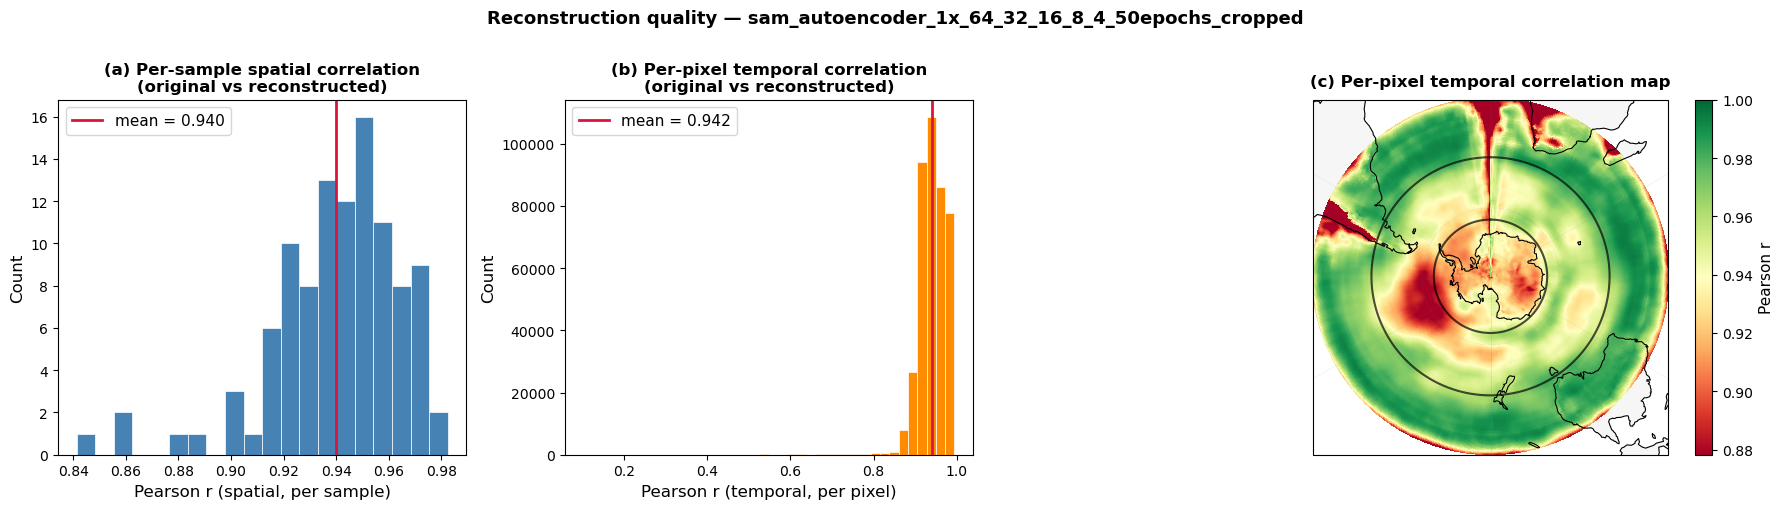

In [9]:
# ── Reconstruction correlation: original vs decoded ──────────────────────────
# Uses x_test (full test set) for a robust estimate.
# Runs in batches to avoid OOM on large grids.

BATCH = 16   # samples per predict call; lower if memory is tight

n_test   = len(x_test)
orig_all = x_test[:, :, :, 0]                   # (N, lat, lon)
rec_list = []
for start in range(0, n_test, BATCH):
    batch = x_test[start : start + BATCH]
    rec_list.append(autoencoder.predict(batch, verbose=0)[:, :, :, 0])
rec_all = np.concatenate(rec_list, axis=0)       # (N, lat, lon)

# ── 1. Per-sample spatial correlation ────────────────────────────────────────
def pearson_r(a, b):
    """Pearson r between two flat arrays (NaN-safe)."""
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    a, b = a[mask], b[mask]
    return float(np.corrcoef(a, b)[0, 1])

sample_r = np.array([
    pearson_r(orig_all[i].ravel(), rec_all[i].ravel())
    for i in range(n_test)
])

print(f"Per-sample spatial Pearson r  —  "
      f"mean: {np.nanmean(sample_r):.4f}  "
      f"std: {np.nanstd(sample_r):.4f}  "
      f"min: {np.nanmin(sample_r):.4f}  "
      f"max: {np.nanmax(sample_r):.4f}")

# ── 2. Per-pixel temporal correlation ────────────────────────────────────────
# Shape: (lat, lon) — correlation over the N test samples at each grid point
n_lat, n_lon = orig_all.shape[1], orig_all.shape[2]

pixel_r = np.full((n_lat, n_lon), np.nan)
for i in range(n_lat):
    for j in range(n_lon):
        pixel_r[i, j] = pearson_r(orig_all[:, i, j], rec_all[:, i, j])

print(f"\nPer-pixel temporal Pearson r  —  "
      f"mean: {np.nanmean(pixel_r):.4f}  "
      f"std: {np.nanstd(pixel_r):.4f}  "
      f"min: {np.nanmin(pixel_r):.4f}  "
      f"max: {np.nanmax(pixel_r):.4f}")

# ── 3. Visualise both distributions + pixel-r map ────────────────────────────
proj_corr = ccrs.SouthPolarStereo()
theta_c   = np.linspace(0, 2 * np.pi, 200)

fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                          gridspec_kw={"width_ratios": [1, 1, 1.6]})

# (a) Per-sample r histogram
ax = axes[0]
ax.hist(sample_r, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(np.nanmean(sample_r), color="crimson", lw=2,
           label=f"mean = {np.nanmean(sample_r):.3f}")
ax.set_xlabel("Pearson r (spatial, per sample)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("(a) Per-sample spatial correlation\n(original vs reconstructed)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)

# (b) Per-pixel r histogram
ax = axes[1]
ax.hist(pixel_r.ravel()[np.isfinite(pixel_r.ravel())], bins=40,
        color="darkorange", edgecolor="white", linewidth=0.5)
ax.axvline(np.nanmean(pixel_r), color="crimson", lw=2,
           label=f"mean = {np.nanmean(pixel_r):.3f}")
ax.set_xlabel("Pearson r (temporal, per pixel)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("(b) Per-pixel temporal correlation\n(original vs reconstructed)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=11)

# (c) Pixel-r map on Southern Hemisphere
ax3 = fig.add_subplot(1, 3, 3, projection=proj_corr)
axes[2].remove()
norm_corr = mcolors.Normalize(vmin=np.nanpercentile(pixel_r, 2),
                               vmax=1.0)
cmap_corr = plt.get_cmap("RdYlGn")
r_c, lon_c = add_cyclic_point(np.ma.masked_invalid(pixel_r),
                               coord=lons_coarse, axis=-1)
ax3.set_extent([-180, 180, -90, -20], ccrs.PlateCarree())
mesh = ax3.pcolormesh(
    *np.meshgrid(lon_c, lats_coarse), r_c,
    norm=norm_corr, cmap=cmap_corr,
    transform=ccrs.PlateCarree(), shading="auto",
    linewidth=0, antialiased=False, edgecolors="face"
)
ax3.coastlines(linewidth=0.8, color="black")
ax3.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.2)
for lat in [-40.0, -65.0]:
    ax3.plot(np.degrees(theta_c), [lat] * 200,
             transform=ccrs.PlateCarree(), color="black",
             linewidth=1.5, alpha=0.7)
ax3.gridlines(draw_labels=False, linewidth=0.5, color="gray",
              alpha=0.3, linestyle=":")
cb = fig.colorbar(mesh, ax=ax3, orientation="vertical",
                  fraction=0.046, pad=0.04)
cb.set_label("Pearson r", fontsize=11)
ax3.set_title("(c) Per-pixel temporal correlation map", fontsize=12,
              fontweight="bold", pad=10)

fig.suptitle(f"Reconstruction quality — {TAG}", fontsize=13,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "reconstruction_correlation.pdf"),
            dpi=300, bbox_inches="tight")
plt.show()


## 1.6 Elbow analysis

**Paper reference**: Supplementary Fig. S2 (`elbow.pdf`). The elbow at *k* = 3
drives the choice of three clusters described in Section 4 (Results).


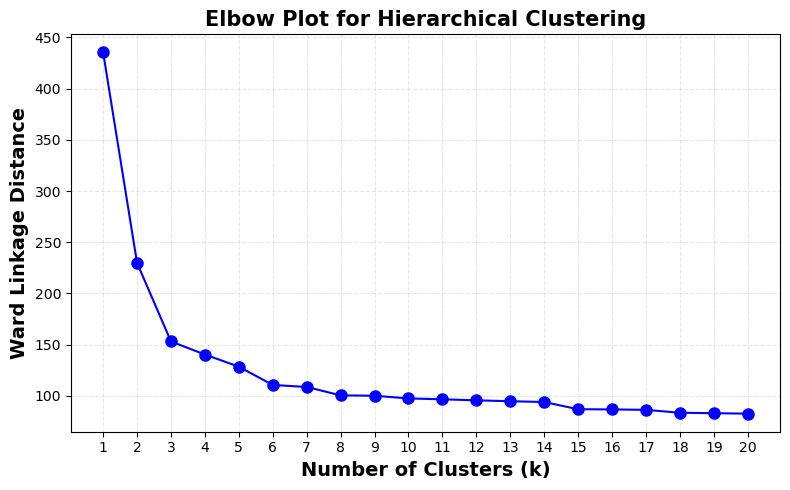

In [10]:
def perform_hierarchical_analysis(encoded_imgs):
    latent_vectors = encoded_imgs.reshape((encoded_imgs.shape[0], -1))
    latent_vectors = StandardScaler().fit_transform(latent_vectors)

    # Compute linkage matrix (ward minimises within-cluster variance, same spirit as KMeans)
    Z = linkage(latent_vectors, method="ward")

    last_merges = Z[-20:, 2][::-1]
    k_values = list(range(1, 21))


    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(k_values, last_merges, marker="o", lw=1.5, markersize=8, color="blue")
    ax.set_xlabel("Number of Clusters (k)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Ward Linkage Distance", fontsize=14, fontweight="bold")
    ax.set_title("Elbow Plot for Hierarchical Clustering", fontsize=15, fontweight="bold")
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3, linestyle="--")

    fig.tight_layout()
    save_dir = 'figures'
    plt.savefig(os.path.join(save_dir, 'elbow.pdf'), dpi=300)

    plt.show()

    return latent_vectors, Z

latent_vectors, Z = perform_hierarchical_analysis(encoded_all)

## 1.7 Cluster visualisation

**Paper reference**: Fig. 2 (`composites.pdf`) — cluster composite anomaly maps.
Section 4 (Results): Cluster 1 (56.6%) = SAM−, Cluster 2 (36.2%) = SAM+,
Cluster 3 (7.2%) = extreme SAM+.


In [11]:
# k=3 chosen based on elbow analysis (Supp. Fig. S2); see Section 4.
N_CLUSTERS = 3


cluster_data, cluster_labels, Z = build_cluster_data(
    encoded_all, data_standardized,
    event_lats_padded, event_lons_padded,
    k=N_CLUSTERS, top_n=N_CLUSTERS,
    max_instances_per_cluster=9,
    avg_coarsen=20,
 
)

Clustering 516 events into 3 clusters (hierarchical, method='ward')...
  Cluster 1: 292 events (56.6%)
  Cluster 2: 37 events (7.2%)
  Cluster 3: 187 events (36.2%)


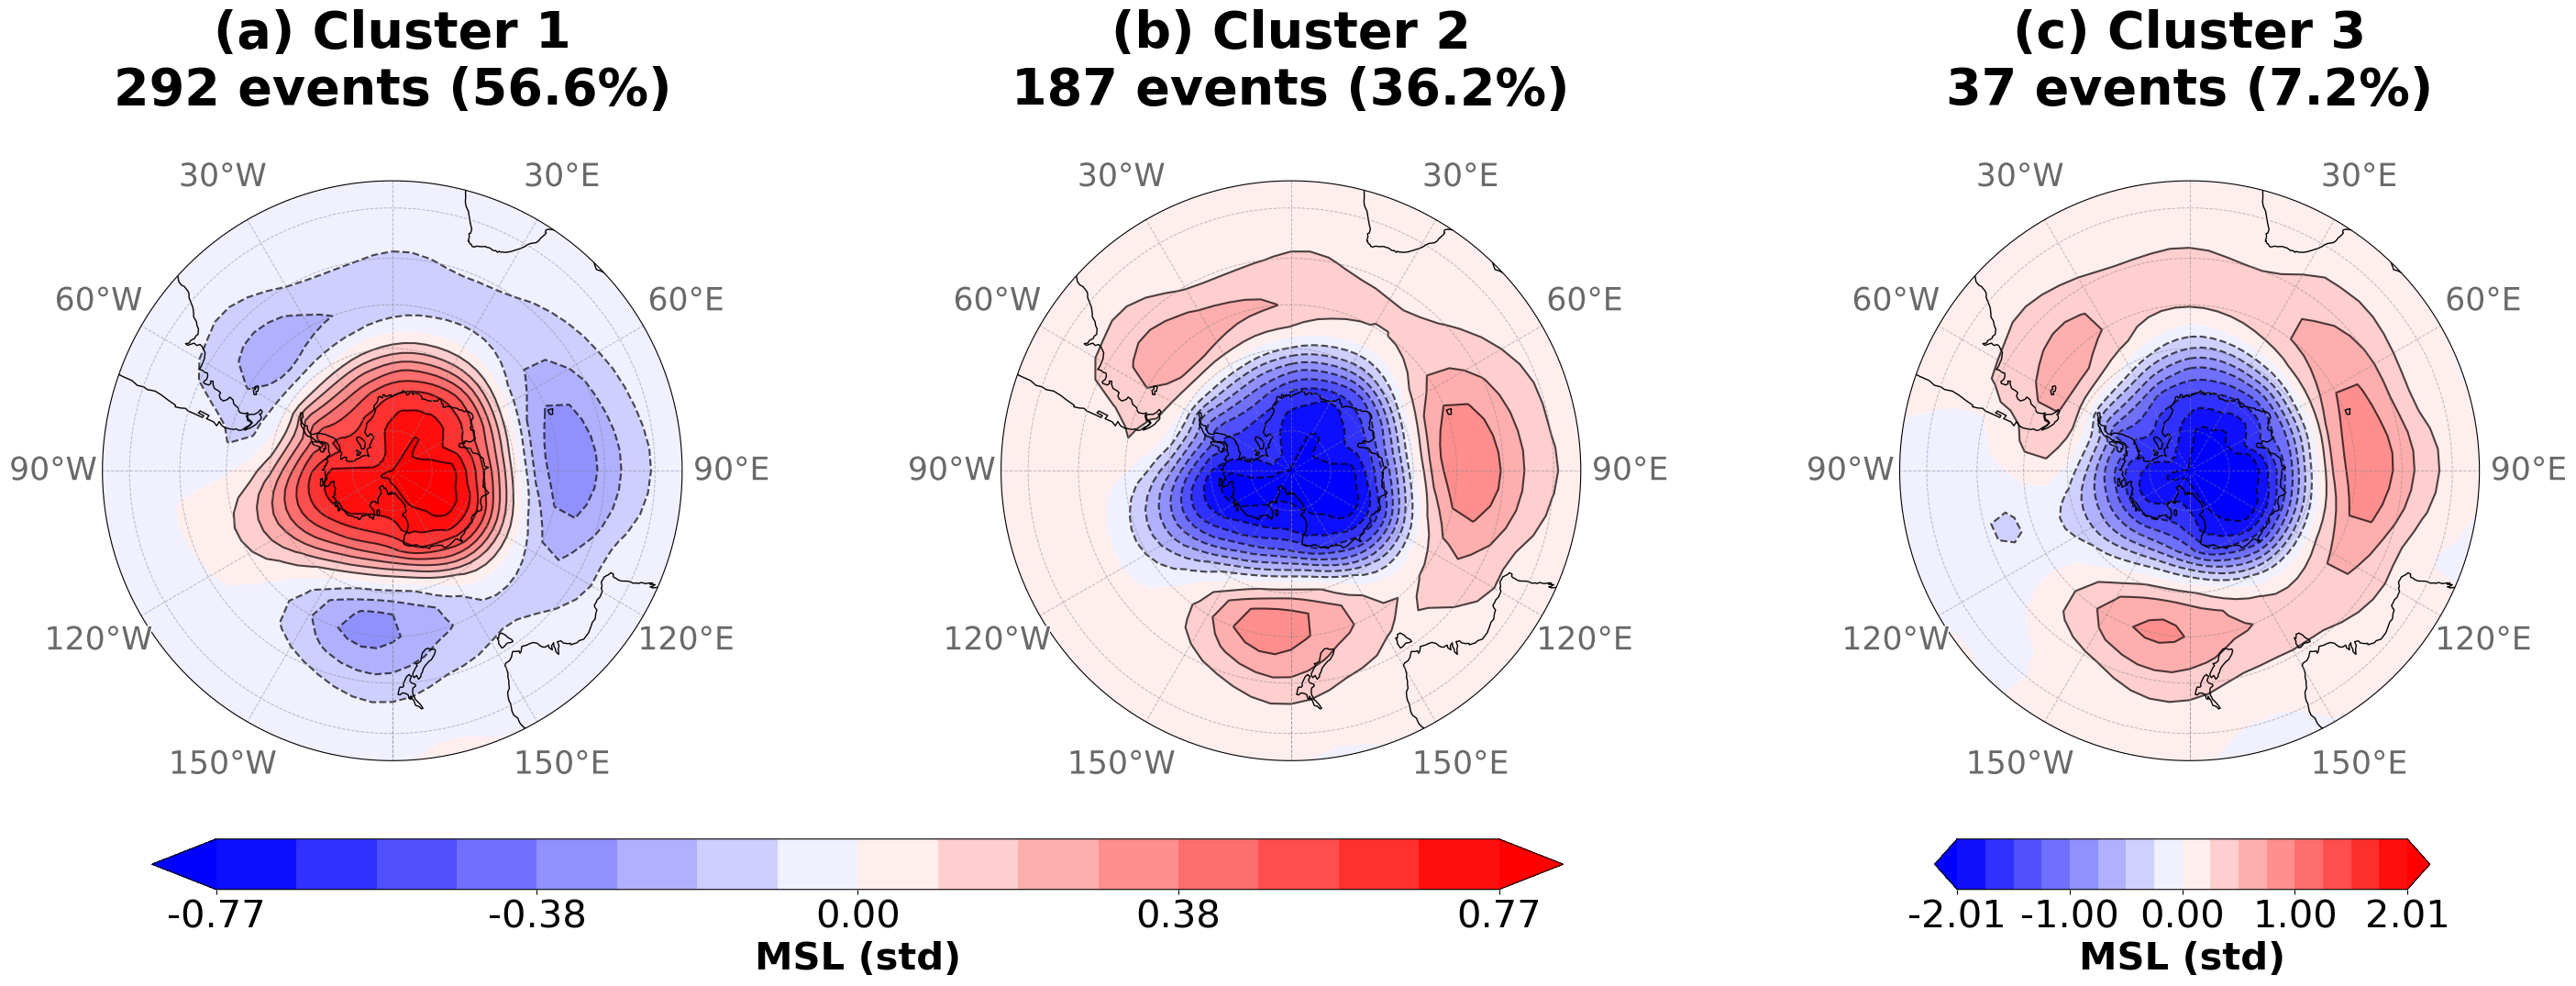

In [12]:
plot_cluster_summary(cluster_data, title_prefix=f"SAM MSL [{TAG}] ")


In [13]:
# ── Build cluster map dataset (ds_ae) ─────────────────────────────────────────
# Requires: cluster_data, lats_coarse, lons_coarse, TAG

cluster_ids     = np.array([ci["cluster_id"] + 1 for ci in cluster_data], dtype=np.int32)
cluster_size    = np.array([len(ci["indices"])   for ci in cluster_data], dtype=np.int32)
cluster_percent = np.array([ci["percent"]        for ci in cluster_data], dtype=np.float32)

if "avg_lats" in cluster_data[0] and "avg_lons" in cluster_data[0]:
    lat_coord = np.asarray(cluster_data[0]["avg_lats"])
    lon_coord = np.asarray(cluster_data[0]["avg_lons"])
else:
    lat_coord = np.asarray(lats_coarse)
    lon_coord = np.asarray(lons_coarse)

cluster_maps = np.stack(
    [np.asarray(ci["avg_original"], dtype=np.float32) for ci in cluster_data], axis=0
)  # (n_clusters, lat, lon)

ds_ae = xr.Dataset(
    data_vars={
        "cluster_map":     (("cluster", "latitude", "longitude"), cluster_maps),
        "cluster_size":    (("cluster",), cluster_size),
        "cluster_percent": (("cluster",), cluster_percent),
    },
    coords={
        "cluster":   cluster_ids,
        "latitude":  lat_coord,
        "longitude": lon_coord,
    },
    attrs={
        "source_notebook": "analyze_autoencoder.ipynb",
        "tag": str(TAG) if "TAG" in globals() else "unknown",
    },
)

print(ds_ae)

Saved: /glade/derecho/scratch/mposternack/ae_cluster_data.nc
<xarray.Dataset> Size: 13kB
Dimensions:          (cluster: 3, latitude: 14, longitude: 72)
Coordinates:
  * cluster          (cluster) int32 12B 1 2 3
  * latitude         (latitude) float64 112B -90.0 -85.0 -80.0 ... -30.0 -25.0
  * longitude        (longitude) float64 576B 0.0 5.0 10.0 ... 345.0 350.0 355.0
Data variables:
    cluster_map      (cluster, latitude, longitude) float32 12kB 0.7508 ... 0...
    cluster_size     (cluster) int32 12B 292 187 37
    cluster_percent  (cluster) float32 12B 56.59 36.24 7.171
Attributes:
    source_notebook:  analyze_autoencoder.ipynb
    tag:              sam_autoencoder_1x_64_32_16_8_4_50epochs_cropped


14855

---
# Part 2: Seasonal Autoencoders

Loads four season-specific autoencoders (DJF, MAM, JJA, SON), performs
per-season hierarchical clustering, and produces composite MSL maps for
each cluster within each season.

**Paper reference**: Seasonal partitioning described in Section 2 (Data):
DJF, MAM, JJA, SON subsets, each detrended independently. Seasonal clustering
results are shown in Figs. 6–9 (`DJF_clusters.pdf` – `SON_clusters.pdf`).
Seasonal elbow analysis: Supplementary Fig. S3 (`season_linkages.pdf`).


## 2.1 Load seasonal data and verify files

In [14]:
season_names = list(SEASON_TAGS.keys())

file_types = ['encoded_all', 'data_standardized', 'lats', 'lons', 'times']
print('=' * 80)
print('  EDA: File check')
print('=' * 80)
print(f"  {'Season':<20}  {'File type':<22}  {'Status':>8}  Shape")
print('  ' + '-' * 74)

all_ok = True
for season, tag in SEASON_TAGS.items():
    for ftype in file_types:
        fpath  = os.path.join(SAVE_DIR, f'{ftype}_{tag}.npy')
        exists = os.path.exists(fpath)
        if exists:
            arr   = np.load(fpath, allow_pickle=True)
            shape = str(arr.shape)
        else:
            shape  = 'MISSING'
            all_ok = False
        print(f'  {season:<20}  {ftype:<22}  {"OK" if exists else "MISSING":>8}  {shape}')
    model_path = os.path.join(SAVE_DIR, f'autoencoder_{tag}.keras')
    exists     = os.path.exists(model_path)
    if not exists:
        all_ok = False
    print(f"  {season:<20}  {'autoencoder.keras':<22}  {'OK' if exists else 'MISSING':>8}")

print('  ' + '-' * 74)
print(f'  All files present: {all_ok}')
print('=' * 80)
print()

print('Loading seasonal data...')
season_data = {}
for season, tag in SEASON_TAGS.items():
    encoded  = np.load(os.path.join(SAVE_DIR, f'encoded_all_{tag}.npy'))
    data_std = np.load(os.path.join(SAVE_DIR, f'data_standardized_{tag}.npy'))
    lats     = np.load(os.path.join(SAVE_DIR, f'lats_{tag}.npy'))
    lons     = np.load(os.path.join(SAVE_DIR, f'lons_{tag}.npy'))
    times    = np.load(os.path.join(SAVE_DIR, f'times_{tag}.npy'), allow_pickle=True)
    n        = data_std.shape[0]
    season_data[season] = {
        'tag':        tag,
        'encoded':    encoded,
        'data_std':   data_std,
        'lats':       lats,
        'lons':       lons,
        'times':      times,
        'indices':    np.arange(n),
        'event_lats': [lats] * n,
        'event_lons': [lons] * n,
    }
    print(f'  {season}: data_std={data_std.shape}  encoded={encoded.shape}')

lats_coarse = season_data[season_names[0]]['lats']
lons_coarse = season_data[season_names[0]]['lons']
print(f'\nLoaded {len(season_data)} seasons.  Grid: {lats_coarse.size} lats x {lons_coarse.size} lons')

  EDA: File check
  Season                File type                 Status  Shape
  --------------------------------------------------------------------------
  DJF                   encoded_all                   OK  (129, 9, 45, 4)
  DJF                   data_standardized             OK  (129, 281, 1440, 1)
  DJF                   lats                          OK  (281,)
  DJF                   lons                          OK  (1440,)
  DJF                   times                         OK  (129,)
  DJF                   autoencoder.keras             OK
  MAM                   encoded_all                   OK  (129, 9, 45, 4)
  MAM                   data_standardized             OK  (129, 281, 1440, 1)
  MAM                   lats                          OK  (281,)
  MAM                   lons                          OK  (1440,)
  MAM                   times                         OK  (129,)
  MAM                   autoencoder.keras             OK
  JJA                   encoded

## 2.2 Per-season data summary

In [15]:
print('=' * 72)
print('  Per-season event summary')
print('=' * 72)
print(f"  {'Season':<20}  {'Events':>8}  Time range")
print('  ' + '-' * 68)
for season in season_names:
    sd    = season_data[season]
    t_min = str(np.array(sd['times'].min(), dtype='datetime64[D]'))
    t_max = str(np.array(sd['times'].max(), dtype='datetime64[D]'))
    print(f"  {season:<20}  {len(sd['indices']):>8,}  {t_min} to {t_max}")
print('=' * 72)


  Per-season event summary
  Season                  Events  Time range
  --------------------------------------------------------------------
  DJF                        129  1980-01-01 to 2022-12-01
  MAM                        129  1980-03-01 to 2022-05-01
  JJA                        129  1980-06-01 to 2022-08-01
  SON                        129  1980-09-01 to 2022-11-01


## 2.3 Model summary stats

In [16]:
print('=' * 72)
print('  Per-season model stats')
print('=' * 72)
print(f"  {'Season':<16}  {'input shape':>20}  {'latent shape':>15}  "
      f"{'input px':>10}  {'latent vals':>12}  {'compression':>12}")
print('  ' + '-' * 68)
for season in season_names:
    sd           = season_data[season]
    input_shape  = sd['data_std'].shape[1:]
    latent_shape = sd['encoded'].shape[1:]
    input_size   = int(np.prod(input_shape))
    latent_size  = int(np.prod(latent_shape))
    compression  = input_size / latent_size
    print(f"  {season:<16}  {str(input_shape):>20}  {str(latent_shape):>15}  "
          f"{input_size:>10,}  {latent_size:>12,}  {compression:>10.1f}x")
print('=' * 72)

  Per-season model stats
  Season                     input shape     latent shape    input px   latent vals   compression
  --------------------------------------------------------------------
  DJF                     (281, 1440, 1)       (9, 45, 4)     404,640         1,620       249.8x
  MAM                     (281, 1440, 1)       (9, 45, 4)     404,640         1,620       249.8x
  JJA                     (281, 1440, 1)       (9, 45, 4)     404,640         1,620       249.8x
  SON                     (281, 1440, 1)       (9, 45, 4)     404,640         1,620       249.8x


In [17]:
print(f'Latitude range : {float(lats_coarse.min()):.2f} to {float(lats_coarse.max()):.2f}')
print(f'Longitude range: {float(lons_coarse.min()):.2f} to {float(lons_coarse.max()):.2f}')
print(f'Grid size      : lat={lats_coarse.size}, lon={lons_coarse.size}')

Latitude range : -90.00 to -20.00
Longitude range: 0.00 to 359.75
Grid size      : lat=281, lon=1440


## 2.4 Per-season elbow analysis

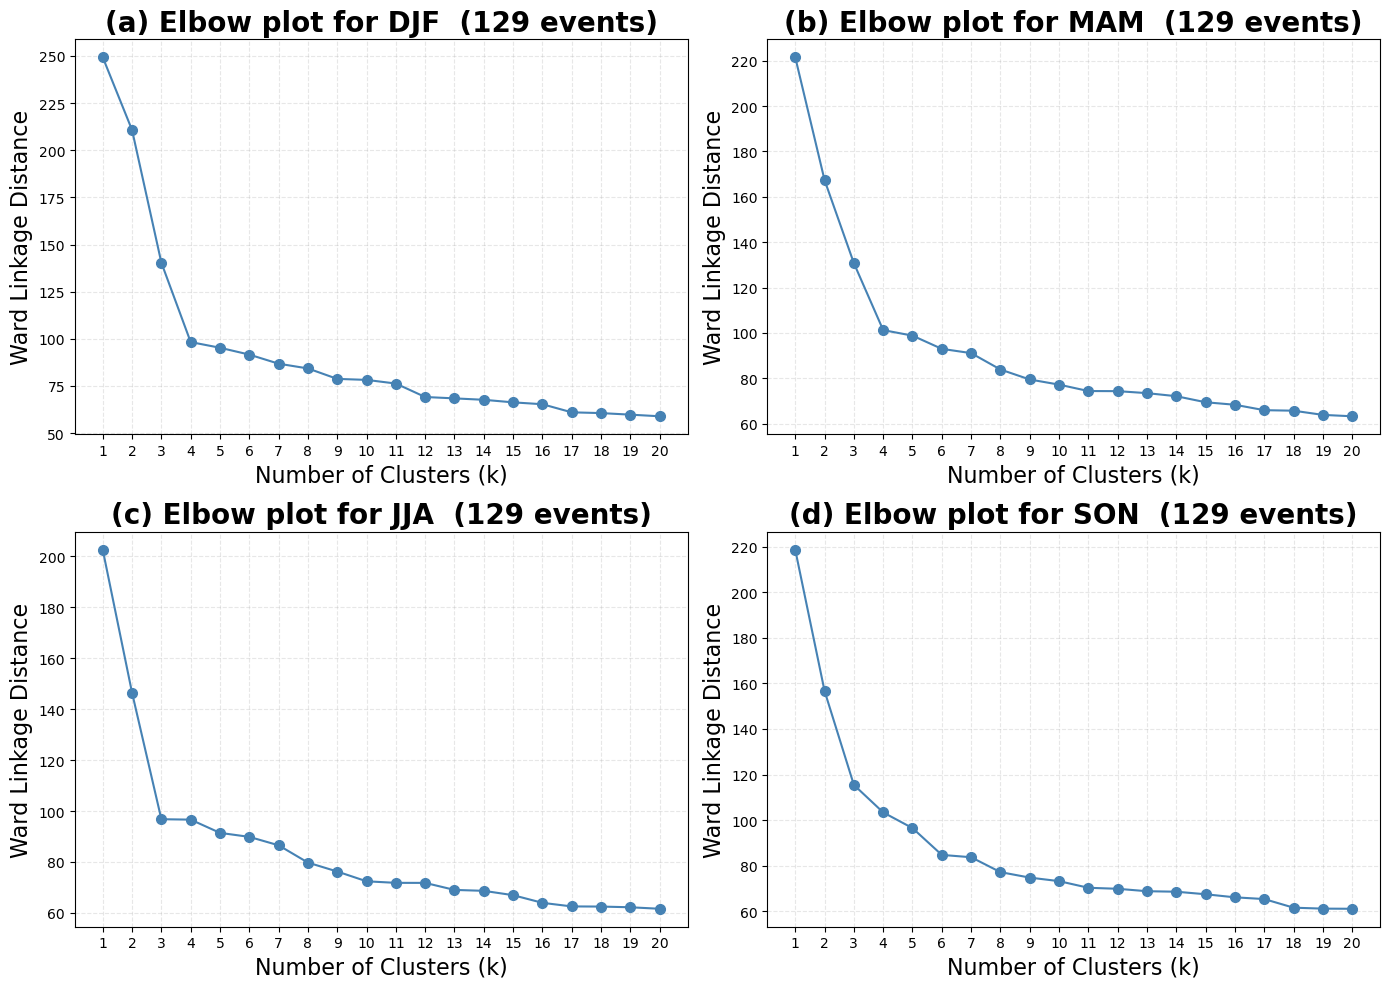

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

season_linkages = {}

for ax, season, panel_lbl in zip(axes.flat, season_names,
                                  ['(a)', '(b)', '(c)', '(d)']):
    sd = season_data[season]
    lv = sd['encoded'].reshape((sd['encoded'].shape[0], -1))
    lv = StandardScaler().fit_transform(lv)
    Z  = linkage(lv, method='ward')
    season_linkages[season] = Z

    last_merges = Z[-20:, 2][::-1]
    k_values    = range(1, 21)
    ax.plot(k_values, last_merges, marker='o', lw=1.5, markersize=7, color='steelblue')
    ax.set_title(f"{panel_lbl} Elbow plot for {season}  ({len(sd['indices'])} events)",
                 fontsize=20, fontweight='bold')
    ax.set_xlabel('Number of Clusters (k)', fontsize=16)
    ax.set_ylabel('Ward Linkage Distance', fontsize=16)
    ax.set_xticks(list(k_values))
    ax.grid(True, alpha=0.3, linestyle='--')

fig.tight_layout()
save_dir = 'figures'
plt.savefig(os.path.join(save_dir, 'season_linkages.pdf'), dpi=300)
plt.show()

## 2.5 Per-season clustering and composite maps

In [19]:
# Cluster counts per season selected by elbow analysis (Supp. Fig. S3).
# DJF/MAM: 4 clusters (Fig. 6–7); JJA/SON: 3 clusters (Fig. 8–9).
N_CLUSTERS_PER_SEASON = {
    'DJF': 4,
    'MAM': 4,
    'JJA': 3,
    'SON': 3,
}

season_cluster_data = {}

for season in season_names:
    sd = season_data[season]
    k  = N_CLUSTERS_PER_SEASON[season]
    print(f"\n{'='*55}")
    print(f"  {season}  -  {len(sd['indices'])} events  ->  {k} clusters")
    print(f"{'='*55}")
    cd, cl, _ = build_cluster_data(
        sd['encoded'], sd['data_std'],
        sd['event_lats'], sd['event_lons'],
        k=k, top_n=k, max_instances_per_cluster=9,
        avg_coarsen=20,
    )
    season_cluster_data[season] = cd
    print('  Done.')


  DJF  -  129 events  ->  4 clusters
Clustering 129 events into 4 clusters (hierarchical, method='ward')...
  Cluster 1: 25 events (19.4%)
  Cluster 2: 24 events (18.6%)
  Cluster 3: 38 events (29.5%)
  Cluster 4: 42 events (32.6%)
  Done.

  MAM  -  129 events  ->  4 clusters
Clustering 129 events into 4 clusters (hierarchical, method='ward')...
  Cluster 1: 26 events (20.2%)
  Cluster 2: 10 events (7.8%)
  Cluster 3: 31 events (24.0%)
  Cluster 4: 62 events (48.1%)
  Done.

  JJA  -  129 events  ->  3 clusters
Clustering 129 events into 3 clusters (hierarchical, method='ward')...
  Cluster 1: 41 events (31.8%)
  Cluster 2: 29 events (22.5%)
  Cluster 3: 59 events (45.7%)
  Done.

  SON  -  129 events  ->  3 clusters
Clustering 129 events into 3 clusters (hierarchical, method='ward')...
  Cluster 1: 20 events (15.5%)
  Cluster 2: 64 events (49.6%)
  Cluster 3: 45 events (34.9%)
  Done.


In [20]:
def compute_eof1(data_std, avg_coarsen=20):
    n    = data_std.shape[0]
    imgs = np.array([_coarsen_img(data_std[i, :, :, 0], avg_coarsen) for i in range(n)])
    X    = imgs.reshape(n, -1).astype(np.float64)
    X   -= X.mean(axis=0)
    _, _, Vt = np.linalg.svd(X, full_matrices=False)
    eof1 = Vt[0].reshape(imgs[0].shape)
    eof1 = eof1 / np.nanmax(np.abs(eof1))   # normalize to [-1, 1]
    if np.nanmean(eof1) < 0:
        eof1 = -eof1
    return eof1


EOF1_ACCENT = '#f0c040'   # golden-amber: EOF-1 title, spine & separator


def plot_season(season, cluster_data, n_clusters, lats, lons, data_std,
                colorbar_groups=None, cluster_vlim=None, 
                avg_coarsen=20,
                label='MSL (std)', quiver_stride=5, quiver_scale=None,
                quiver_color='black'):
    """Cluster maps and EOF reference panel.

    Manual color limits (``None`` keeps auto scaling from the 85th percentile
    of |field| within each colorbar group):

    * ``eof_vlim`` — EOF panel only. A number sets symmetric ``(-v, v)``;
      a pair ``(vmin, vmax)`` sets both ends explicitly.
    * ``cluster_vlim`` — keys are cluster indices ``0 .. n_clusters-1``. Same
      number vs pair rule. If ``colorbar_groups`` merges clusters, every index
      in that group is drawn with the combined span
      ``[min(vmins), max(vmaxs)]`` so the shared colorbar matches all panels.
    """
    n_k          = n_clusters
    n_panels     = 1 + n_k
    cluster_vlim = cluster_vlim or {}

    eof1      = compute_eof1(data_std, avg_coarsen=avg_coarsen)
    H2        = (len(lats) // avg_coarsen) * avg_coarsen
    W2        = (len(lons) // avg_coarsen) * avg_coarsen
    eof1_lats = lats[:H2:avg_coarsen]
    eof1_lons = lons[:W2:avg_coarsen]
   
    groups = (colorbar_groups)
    all_in_groups = sorted([idx for g in groups for idx in g])
    if all_in_groups != list(range(n_k)):
        raise ValueError(
            f"colorbar_groups['{season}'] must cover indices 0..{n_k-1} exactly once. "
            f"Got: {all_in_groups}"
        )

    cluster_vmax_d = {}
    cluster_vmin_d = {}
    for group in groups:
        gmax = max(
            max(np.percentile(np.abs(np.nan_to_num(
                cluster_data[i]['avg_original'], nan=0.0)), 85) for i in group),
            0.0001,
        )
        for i in group:
            cluster_vmax_d[i] = gmax
            cluster_vmin_d[i] = -gmax
    for idx, override in cluster_vlim.items():
        if isinstance(override, (int, float)):
            cluster_vmax_d[idx] = float(override)
            cluster_vmin_d[idx] = -float(override)
        else:
            cluster_vmin_d[idx], cluster_vmax_d[idx] = float(override[0]), float(override[1])

    for group in groups:
        gvmin = min(cluster_vmin_d[i] for i in group)
        gvmax = max(cluster_vmax_d[i] for i in group)
        for i in group:
            cluster_vmin_d[i] = gvmin
            cluster_vmax_d[i] = gvmax

    fig = plt.figure(figsize=(9.0 * n_panels + 1.5, 12))
    gs  = GridSpec(
        2, n_panels, figure=fig,
        height_ratios=[14, 1], width_ratios=[1.0] * n_panels,
        hspace=0.00, wspace=0.55,
        left=0.04, right=0.98, top=0.96, bottom=0.05,
    )

    ax_eof = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
    cf_eof, _ = _polar_map(
        ax_eof, eof1_lons, eof1_lats, eof1,
        title=f'(a) {season} EOF 1\n  reference',
       add_colorbar=False,
    )
    ax_eof.set_title(ax_eof.get_title(), fontsize=40, fontweight='bold',
                     color=EOF1_ACCENT, pad=60)

    cax_eof  = fig.add_subplot(gs[1, 0])
    cbar_eof = fig.colorbar(cf_eof, cax=cax_eof, orientation='horizontal')
    cbar_eof.set_ticks(np.linspace(-1, 1, 3))
    cbar_eof.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    cbar_eof.ax.tick_params(labelsize=30)
    cbar_eof.set_label(label, fontsize=36, fontweight='bold')

    try:
        ax_eof.spines['geo'].set_linewidth(8)
        ax_eof.spines['geo'].set_edgecolor(EOF1_ACCENT)
    except KeyError:
        ax_eof.outline_patch.set_linewidth(8)
        ax_eof.outline_patch.set_edgecolor(EOF1_ACCENT)

    row_cfs          = {}
    first_cluster_ax = None
    for col_idx, ci in enumerate(cluster_data):
        gs_col = 1 + col_idx
        vmax_c = cluster_vmax_d[col_idx]
        vmin_c = cluster_vmin_d[col_idx]
        ax = fig.add_subplot(gs[0, gs_col], projection=ccrs.SouthPolarStereo())
        if first_cluster_ax is None:
            first_cluster_ax = ax
        cf, _ = _polar_map(
            ax, ci['avg_lons'], ci['avg_lats'], ci['avg_original'],
            title=(f'({chr(ord("b") + col_idx)}) '
                   f'{season} Cluster {ci["cluster_id"] + 1}\n'
                   f'{ci["size"]} events ({ci["percent"]:.1f}%)'),
            u_wind=ci.get('avg_u'), v_wind=ci.get('avg_v'),
            wind_lons=ci.get('wind_lons'), wind_lats=ci.get('wind_lats'),
            quiver_stride=quiver_stride, quiver_scale=quiver_scale,
            quiver_color=quiver_color,
            vmax=vmax_c, vmin=vmin_c, add_colorbar=False,
        )
        ax.set_title(ax.get_title(), fontsize=40, fontweight='bold', pad=60)
        row_cfs[col_idx] = cf

    for group in groups:
        g_vmax    = cluster_vmax_d[group[0]]
        g_vmin    = cluster_vmin_d[group[0]]
        col_start = 1 + min(group)
        col_end   = 1 + max(group)
        cax  = fig.add_subplot(gs[1, col_start:col_end + 1])
        cbar = fig.colorbar(row_cfs[group[0]], cax=cax, orientation='horizontal')
        cbar.set_ticks(np.linspace(g_vmin, g_vmax, 3))
        cbar.ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        cbar.ax.tick_params(labelsize=30)
        cbar.set_label(label, fontsize=36, fontweight='bold')

    if first_cluster_ax is not None:
        fig.canvas.draw()
        p_eof = ax_eof.get_position()
        p_c1  = first_cluster_ax.get_position()
        x_sep = (p_eof.x1 + p_c1.x0) / 2
        sep   = Line2D([x_sep, x_sep], [0.02, 0.98],
                       transform=fig.transFigure,
                       color=EOF1_ACCENT, linewidth=3,
                       linestyle='--', clip_on=False, zorder=10)
        fig.add_artist(sep)

    save_dir = 'figures'
    plt.savefig(os.path.join(save_dir, f'{season}_clusters.pdf'), dpi=300, bbox_inches='tight')
    plt.show()


TypeError: _polar_map() got an unexpected keyword argument 'u_wind'

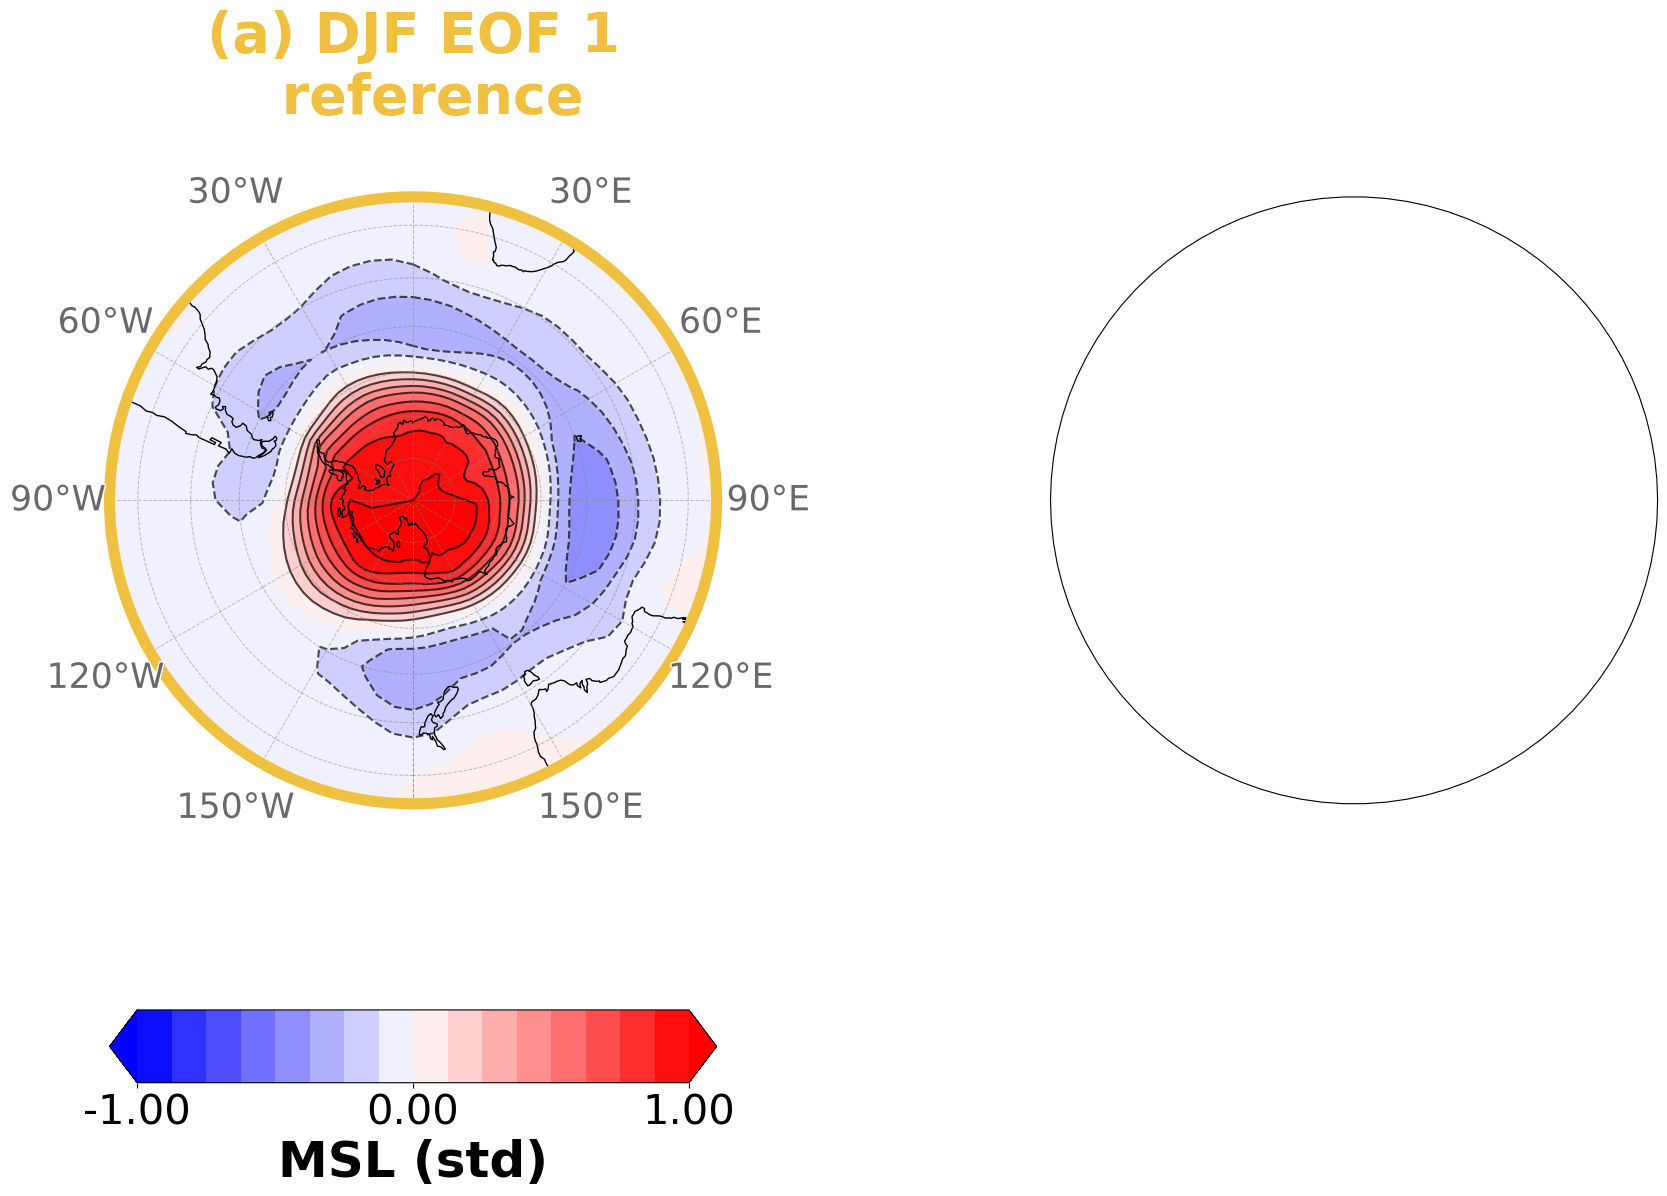

In [21]:
season = 'DJF'  # Paper Fig. 6 (DJF_clusters.pdf)
sd = season_data[season]
plot_season(
    season,
    season_cluster_data[season],
    N_CLUSTERS_PER_SEASON[season],
    sd['lats'], sd['lons'], sd['data_std'],
    colorbar_groups=[[0], [1], [2,3]],
    cluster_vlim= {0:.5, 1:.75, 2:1.8, 3:1.8},
    avg_coarsen=20,
)

In [ ]:
season = 'MAM'  # Paper Fig. 7 (MAM_clusters.pdf)
sd = season_data[season]
plot_season(
    season,
    season_cluster_data[season],
    N_CLUSTERS_PER_SEASON[season],
    sd['lats'], sd['lons'], sd['data_std'],
    colorbar_groups=[[0], [1], [2,3]],
    cluster_vlim= {0: .25, 1: .75, 2: 1.7, 3:1.7},
    avg_coarsen=20,
)

In [ ]:
season = 'JJA'  # Paper Fig. 8 (JJA_clusters.pdf)
sd = season_data[season]
plot_season(
    season,
    season_cluster_data[season],
    N_CLUSTERS_PER_SEASON[season],
    sd['lats'], sd['lons'], sd['data_std'],
    colorbar_groups=[[0], [1,2]],
    cluster_vlim= {0: .25, 1: 1.25, 2: 1.25},
    avg_coarsen=20,
)

In [ ]:
season = 'SON'  # Paper Fig. 9 (SON_clusters.pdf)
sd = season_data[season]
plot_season(
    season,
    season_cluster_data[season],
    N_CLUSTERS_PER_SEASON[season],
    sd['lats'], sd['lons'], sd['data_std'],
    colorbar_groups=[[0], [1, 2]],
    cluster_vlim= {0: .3, 1: 1.25, 2: 1.25},
    avg_coarsen=20,
)

## 2.6 Reconstruction quality per season

In [ ]:
BATCH = 8   # reduce if kernel crashes

def _pearson_r_flat(a, b):
    mask = np.isfinite(a) & np.isfinite(b)
    if mask.sum() < 2:
        return np.nan
    a, b = a[mask], b[mask]
    return float(np.corrcoef(a, b)[0, 1])

print(f"{'Season':<20}  {'N':>4}  {'sample-r mean':>14}  "
      f"{'sample-r std':>13}  {'pixel-r mean':>13}")
print('-' * 70)

for season in season_names:
    tag  = SEASON_TAGS[season]
    orig = season_data[season]['data_std'][:, :, :, 0]
    N    = orig.shape[0]
    ae   = keras.models.load_model(os.path.join(SAVE_DIR, f'autoencoder_{tag}.keras'))
    rec_parts = [
        ae.predict(season_data[season]['data_std'][s:s+BATCH], verbose=0)[:, :, :, 0]
        for s in range(0, N, BATCH)
    ]
    rec = np.concatenate(rec_parts, axis=0)
    del ae, rec_parts; gc.collect()
    sample_r = np.array([_pearson_r_flat(orig[i].ravel(), rec[i].ravel())
                          for i in range(N)])
    pixel_r  = np.array([
        _pearson_r_flat(orig[:, ii, jj], rec[:, ii, jj])
        for ii in range(orig.shape[1])
        for jj in range(orig.shape[2])
    ])
    print(f"{season:<20}  {N:>4}  "
          f"{np.nanmean(sample_r):>14.4f}  {np.nanstd(sample_r):>13.4f}  "
          f"{np.nanmean(pixel_r):>13.4f}")
    del orig, rec, sample_r, pixel_r; gc.collect()

---
# Part 3: Time Series Analysis and SAM Index Comparison

Constructs a SAM index from the autoencoder cluster patterns via
change-of-basis projection and compares it against the EOF-based SAM
index and the Marshall station-based AAO index.

**Requires**: `$SCRATCH/ae_cluster_data.nc` (saved at end of Part 1)

**Paper reference**: Change-of-basis construction defined in Section 3.2,
Eqs. (1)–(4). Comparison with EOF framework: Section 4 (Results).
Figs. 3–5 (`time.pdf`, `corr.pdf`, `compare.pdf`).


## 3.1 Load cluster maps and EOF data

In [ ]:
EOF_FILE = os.path.join(OUT_DIR, "sam_pca_data.nc")

ds_eof = xr.open_dataset(EOF_FILE)
print(ds_ae)
print(ds_eof)

In [ ]:
cluster_map  = ds_ae["cluster_map_used"] if "cluster_map_used" in ds_ae else ds_ae["cluster_map"]
cluster_ids  = cluster_map["cluster"].values

eofs     = ds_eof["eofs"]   # (mode, lat, lon)
pcs      = ds_eof["pcs"]    # (time, mode)
mode_ids = eofs["mode"].values
var_exp  = ds_eof["variance_explained"].values if "variance_explained" in ds_eof else np.full(len(mode_ids), np.nan)
pc_time  = pd.to_datetime(pcs["time"].values)

print("cluster_map  :", cluster_map.shape)
print("eofs         :", eofs.shape)
print("pcs          :", pcs.shape)


## 3.2 Helper functions

In [ ]:
FS_TITLE = 26
FS_LABEL = 22
FS_TICK  = 18
FS_ANNOT = 15

def spatial_corr(a2d, b2d):
    a = np.asarray(a2d).ravel().astype(float)
    b = np.asarray(b2d).ravel().astype(float)
    m = np.isfinite(a) & np.isfinite(b)
    a, b = a[m] - a[m].mean(), b[m] - b[m].mean()
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0: return np.nan
    return np.dot(a, b) / (na * nb)

def _zmap_field(vals):
    x = np.asarray(vals, dtype=float)
    return (x - np.nanmean(x[np.isfinite(x)])) / (np.nanstd(x[np.isfinite(x)]) + 1e-12)

def _safe_levels(vals, pct=85, n=17):
    arr = np.asarray(vals, dtype=float).ravel()
    arr = arr[np.isfinite(arr)]
    vmax = np.percentile(np.abs(arr), pct) if arr.size else 1.0
    return np.linspace(-max(vmax, 1e-6), max(vmax, 1e-6), n)

def _fill_gaps(vals):
    filled = vals.copy()
    for i in range(filled.shape[0]):
        row = filled[i]; nans = np.isnan(row)
        if nans.any() and (~nans).sum() > 2:
            idx = np.arange(len(row))
            filled[i] = np.interp(idx, idx[~nans], row[~nans])
    for j in range(filled.shape[1]):
        col = filled[:, j]; nans = np.isnan(col)
        if nans.any() and (~nans).sum() > 2:
            idx = np.arange(len(col))
            filled[:, j] = np.interp(idx, idx[~nans], col[~nans])
    return filled

def _plot_polar(ax, da, title, levels=None, sign=1):
    import matplotlib.path as mpath
    theta  = np.linspace(0, 2 * np.pi, 200)
    circle = mpath.Path(np.column_stack([np.sin(theta), np.cos(theta)]) * 0.5 + 0.5)
    ax.set_boundary(circle, transform=ax.transAxes)
    pc   = ccrs.PlateCarree()
    da   = da.transpose("latitude", "longitude", missing_dims="ignore")
    vals = sign * np.asarray(da.values, dtype=float)
    lon  = np.asarray(da["longitude"].values, dtype=float)
    lat  = np.asarray(da["latitude"].values,  dtype=float)
    vals = _fill_gaps(vals)
    if levels is None: levels = _safe_levels(vals)
    idx  = np.argsort(lon); lon = lon[idx]; vals = vals[:, idx]
    dlon = np.nanmedian(np.diff(lon))
    if np.isfinite(dlon) and dlon > 0 and np.isclose(lon[-1] - lon[0], 360., atol=0.75 * dlon):
        lon = lon[:-1]; vals = vals[:, :-1]
    vals_c, lon_c = add_cyclic_point(vals, coord=lon)
    cf = ax.contourf(lon_c, lat, vals_c, levels=levels, transform=pc, cmap="bwr", extend="both")
    pos_lev = levels[levels > 0]; neg_lev = levels[levels < 0]
    kw = dict(transform=pc, colors="black", linewidths=1.5, alpha=1)
    if len(pos_lev): ax.contour(lon_c, lat, vals_c, levels=pos_lev, linestyles="solid",  **kw)
    if len(neg_lev): ax.contour(lon_c, lat, vals_c, levels=neg_lev, linestyles="dashed", **kw)
    ax.coastlines(linewidth=1.5, color="black")
    ax.set_extent([-180, 180, -90, -20], pc)
    gl = ax.gridlines(crs=pc, draw_labels=False, linewidth=0.7, color="black", alpha=0.5, linestyle="--")
    gl.xlocator = mticker.FixedLocator(range(-180, 181, 30))
    gl.ylocator = mticker.FixedLocator([-80, -70, -60, -50, -40, -30])
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=10)
    return cf

def _heatmap(ax, mat, title_line1, title_line2):
    im = ax.imshow(mat.values, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=FS_TICK)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=FS_TICK)
    for (r, c_), val in np.ndenumerate(mat.values):
        ax.text(c_, r, f"{val:.2f}", ha="center", va="center", fontsize=FS_ANNOT,
                color="white" if abs(val) > 0.5 else "black", fontweight="bold")
    ax.set_title(f"{title_line1}\n{title_line2}", fontsize=FS_TITLE, fontweight="bold", pad=10)
    return im

## 3.3 EOF spatial patterns and PC time series

In [ ]:
n_modes = len(mode_ids)
nrows = (n_modes + 1) // 2

fig = plt.figure(figsize=(16, 7 * nrows))
for i, mode in enumerate(mode_ids):
    eof = eofs.sel(mode=mode)
    ax  = fig.add_subplot(nrows, 2, i + 1, projection=ccrs.SouthPolarStereo())
    da  = xr.DataArray(eof.values, coords={"latitude": eof.latitude, "longitude": eof.longitude},
                       dims=["latitude", "longitude"])
    levels = _safe_levels(eof.values)
    cf = _plot_polar(ax, da, f"EOF {int(mode)}  ({var_exp[i]*100:.1f}% var)" if np.isfinite(var_exp[i])
                    else f"EOF {int(mode)}", levels=levels)
plt.suptitle("EOF Spatial Patterns", fontsize=FS_TITLE, fontweight="bold")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_modes, 1, figsize=(15, 3 * n_modes), sharex=True)
if n_modes == 1: axes = [axes]
for i, mode in enumerate(mode_ids):
    pc = pcs.sel(mode=mode).values
    axes[i].plot(pc_time, pc, lw=0.9, color="black")
    axes[i].axhline(0, color="black", lw=0.7, ls="--", alpha=0.6)
    axes[i].fill_between(pc_time, 0, pc, where=(pc >= 0), color="red",  alpha=0.22)
    axes[i].fill_between(pc_time, 0, pc, where=(pc <  0), color="blue", alpha=0.22)
    axes[i].set_ylabel(f"PC{int(mode)}", fontsize=FS_LABEL)
    axes[i].grid(alpha=0.25, linestyle=":")
axes[-1].set_xlabel("Year", fontsize=FS_LABEL)
plt.suptitle("PC Time Series", fontsize=FS_TITLE, fontweight="bold")
plt.tight_layout()
plt.show()

## 3.4 Cluster spatial patterns

In [ ]:
n_clusters = len(cluster_ids)
fig = plt.figure(figsize=(7 * n_clusters, 7))
for i, cid in enumerate(cluster_ids):
    ax  = fig.add_subplot(1, n_clusters, i + 1, projection=ccrs.SouthPolarStereo())
    cda = cluster_map.sel(cluster=cid)
    da  = xr.DataArray(cda.values, coords={"latitude": cda.latitude, "longitude": cda.longitude},
                       dims=["latitude", "longitude"])
    cf  = _plot_polar(ax, da, f"Cluster {int(cid)}", levels=_safe_levels(cda.values))
plt.suptitle("Cluster Spatial Patterns", fontsize=FS_TITLE, fontweight="bold")
plt.tight_layout()
plt.show()

# Cluster coefficient time series are recomputed via change-of-basis
# projection in Section 4 below.
if cluster_coeff is not None:
    fig, axes = plt.subplots(n_clusters, 1, figsize=(15, 3 * n_clusters), sharex=True)
    if n_clusters == 1: axes = [axes]
    for i, cid in enumerate(cluster_ids):
        ts = cluster_coeff.sel(cluster=cid).values
        axes[i].plot(cluster_time, ts, lw=0.9, color="black")
        axes[i].axhline(0, color="black", lw=0.7, ls="--", alpha=0.6)
        axes[i].set_ylabel(f"c{int(cid)}(t)", fontsize=FS_LABEL)
        axes[i].grid(alpha=0.3, linestyle=":")
    axes[-1].set_xlabel("Year", fontsize=FS_LABEL)
    plt.suptitle("Cluster Coefficient Time Series", fontsize=FS_TITLE, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 3.5 Change-of-basis projection: constructing the SAM index

**Paper reference**: Section 3.2, Eqs. (1)–(4).
- `c_avg = 0.5*(c1 - c2)` (Eq. 1): shared annular structure; compare with EOF1.
- `c_diff = 0.5*(c1 + c2)` (Eq. 2): deviations from phase symmetry.
- `T_avg(t) = <MSL(t), c_avg>` (Eq. 3): SAM amplitude time series.
- `T_diff(t) = <MSL(t), c_diff>` (Eq. 4): asymmetry time series.


In [ ]:
SLP_FILE    = os.path.join(OUT_DIR, "sam_preprocessed_data.nc")
ds_slp      = xr.open_dataset(SLP_FILE, chunks={"time": 64})
slp_field   = ds_slp["removed_trend_and_climatology"]

lat_lo = float(cluster_map.latitude.min())
lat_hi = float(cluster_map.latitude.max())
slp_field = slp_field.sel(
    latitude=slice(lat_lo, lat_hi) if float(slp_field.latitude[0]) <= float(slp_field.latitude[-1])
    else slice(lat_hi, lat_lo)
)
slp_on_clust = slp_field.interp(
    latitude=cluster_map.latitude.values,
    longitude=cluster_map.longitude.values,
    method="nearest",
)

common_times = np.intersect1d(
    slp_on_clust.time.values.astype("datetime64[ns]"),
    pcs.time.values.astype("datetime64[ns]"),
)
if common_times.size == 0:
    raise ValueError("No overlapping time steps.")

slp_common  = slp_on_clust.sel(time=common_times).compute()
direct_time = pd.to_datetime(common_times)
ds_slp.close()

print(f"SLP shape : {slp_common.shape}")
print(f"Time range: {direct_time[0].date()} – {direct_time[-1].date()}  ({len(direct_time)} steps)")

In [ ]:
# ── Basis patterns ────────────────────────────────────────────────────────────
a1 = cluster_map.sel(cluster=cluster_ids[0]).values.astype(np.float64)
a2 = cluster_map.sel(cluster=cluster_ids[1]).values.astype(np.float64)

# c_prime : (cluster1 - cluster2) / 2  →  average SAM pattern
# c_diff  : (cluster1 + cluster2) / 2  →  difference between +/- SAM states
c_prime = (a1 - a2) / 2.0
c_diff  = (a1 + a2) / 2.0

# ── Project SLP anomaly onto c_prime at every time step ───────────────────────
# T_t = sum_{lat,lon}[ SLP_t(lat,lon) * c_prime(lat,lon) ]
# (dot product over the spatial grid; NaN grid points are zeroed)
n_lat, n_lon = a1.shape
n_grid = n_lat * n_lon

c_prime_flat = c_prime.ravel()
c_prime_flat = np.where(np.isfinite(c_prime_flat), c_prime_flat, 0.0)

B_raw  = slp_common.values.astype(np.float64).reshape(-1, n_grid)
B      = np.where(np.isfinite(B_raw), B_raw, 0.0)

T_raw  = B @ c_prime_flat          # (n_time,)  raw dot product

T_sam = T_raw

print(f"c_prime range : {c_prime.min():.4f}  to  {c_prime.max():.4f}")
print(f"T_sam  range  : {T_sam.min():.4f}  to  {T_sam.max():.4f}")
print(f"T_sam  mean   : {T_sam.mean():.4f}    std: {T_sam.std():.4f}")

In [ ]:
# Basis patterns figure (Section 3.2, Fig. 3 row a/c in paper; see compare.pdf for side-by-side).
shared_levels = _safe_levels(np.concatenate([c_prime.ravel(), c_diff.ravel()]))

fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1, 0.06], hspace=0.15, wspace=0.1)

for i, (arr, title) in enumerate([
    (c_prime, "c1 - c2  / 2 (avg SAM)"),
    (c_diff,  " c1 + c2  / 2 (DIF)"),
]):
    da = xr.DataArray(arr, coords={"latitude": cluster_map.latitude,
                                   "longitude": cluster_map.longitude},
                      dims=["latitude", "longitude"])
    ax = fig.add_subplot(gs[0, i], projection=ccrs.SouthPolarStereo())
    cf = _plot_polar(ax, da, title, levels=shared_levels)

ax_cb = fig.add_subplot(gs[1, :])
cbar  = fig.colorbar(cf, cax=ax_cb, orientation="horizontal")
cbar.set_label("hPa", fontsize=FS_LABEL)
cbar.ax.tick_params(labelsize=FS_TICK)
plt.suptitle("Basis Patterns", fontsize=FS_TITLE, fontweight="bold")
plt.savefig(os.path.join("figures", "basis_patterns.pdf"), dpi=150, bbox_inches="tight")
plt.show()

## 3.6 Comparison with EOF-based SAM index

**Paper reference**: Section 4 (Results).
- Fig. 4 (`corr.pdf`): spatial and temporal correlation heatmaps. c_avg is
  98% correlated with EOF1; T_avg is 97% correlated with PC1.
- Fig. 5 (`compare.pdf`): side-by-side visual comparison of EOF vs CAE
  spatial patterns, time series, and residuals.


In [ ]:
TARGET_MODE = 1   # which EOF/PC to compare against

eof_da  = eofs.sel(mode=TARGET_MODE)
grids_match = (np.array_equal(cluster_map.latitude.values,  eof_da.latitude.values) and
               np.array_equal(cluster_map.longitude.values, eof_da.longitude.values))
c_prime_da = xr.DataArray(c_prime, coords={"latitude": cluster_map.latitude,
                                            "longitude": cluster_map.longitude},
                           dims=["latitude", "longitude"])
c_prime_on_eof = c_prime_da.interp(latitude=eof_da.latitude, longitude=eof_da.longitude) \
                 if not grids_match else c_prime_da

s_spatial = spatial_corr(c_prime_on_eof.values, -1.0 * eof_da.values)
print(f"Spatial corr (c_prime vs −1×EOF{TARGET_MODE}): {s_spatial:.3f}")

# Standardised spatial fields
cp_z   = xr.DataArray(_zmap_field(c_prime_on_eof.values),
                       coords=c_prime_on_eof.coords, dims=c_prime_on_eof.dims)
eof_z  = xr.DataArray(_zmap_field(eof_da.values),
                       coords={"latitude": eof_da.latitude, "longitude": eof_da.longitude},
                       dims=["latitude", "longitude"])
diff_map = (cp_z - (-1.0 * eof_z)).transpose("latitude", "longitude")

# Time series
p_ts  = pd.Series(-1.0 * pcs.sel(mode=TARGET_MODE).values, index=pc_time)
c_ts  = pd.Series(T_sam, index=direct_time)
common_d = c_ts.index.intersection(p_ts.index)
c_raw = c_ts.loc[common_d].values.astype(float)
p_raw = p_ts.loc[common_d].values.astype(float)
cz = (c_raw - np.nanmean(c_raw)) / (np.nanstd(c_raw) + 1e-12)
pz = (p_raw - np.nanmean(p_raw)) / (np.nanstd(p_raw) + 1e-12)
diff_ts = cz - pz

_dt  = (pd.DatetimeIndex(common_d)[1] - pd.DatetimeIndex(common_d)[0]).days if len(common_d) > 1 else 365
_win = max(3, int(365.25 * 10 / _dt))
cz_dec  = pd.Series(cz,      index=common_d).rolling(_win, center=True, min_periods=_win//3).mean()
pz_dec  = pd.Series(pz,      index=common_d).rolling(_win, center=True, min_periods=_win//3).mean()
dt_dec  = pd.Series(diff_ts, index=common_d).rolling(_win, center=True, min_periods=_win//3).mean()

corr_raw = np.corrcoef(c_raw, p_raw)[0, 1]
corr_z   = np.corrcoef(cz,   pz)[0, 1]

# ── Figure ────────────────────────────────────────────────────────────────────
fig_d = plt.figure(figsize=(20, 20))
gs_d  = fig_d.add_gridspec(4, 2, height_ratios=[1, 1, 1, 0.08],
                            width_ratios=[1, 1.4], hspace=0.28, wspace=0.22)

ax_m0 = fig_d.add_subplot(gs_d[0, 0], projection=ccrs.SouthPolarStereo())
ax_m1 = fig_d.add_subplot(gs_d[1, 0], projection=ccrs.SouthPolarStereo())
ax_m2 = fig_d.add_subplot(gs_d[2, 0], projection=ccrs.SouthPolarStereo())
ax_cb = fig_d.add_subplot(gs_d[3, 0])
ax_t0 = fig_d.add_subplot(gs_d[0, 1])
ax_t1 = fig_d.add_subplot(gs_d[1, 1])
ax_t2 = fig_d.add_subplot(gs_d[2, 1])

shared_levels_d = _safe_levels(np.concatenate([
    (-1.0 * eof_z).values.ravel(), cp_z.values.ravel(), diff_map.values.ravel()]))

cfs_d = []
for ax, da, ttl, sgn in [
    (ax_m0, eof_z,    f"(a) EOF Mode {TARGET_MODE}",          -1),
    (ax_m1, cp_z,      "(c) Average SAM: (c1 - c2)/2",   1),
    (ax_m2, diff_map,  f"(e) Residual: Average SAM − EOF{TARGET_MODE}", 1),
]:
    cfs_d.append(_plot_polar(ax, da, ttl, levels=shared_levels_d, sign=sgn))

cbar_d = fig_d.colorbar(cfs_d[0], cax=ax_cb, orientation="horizontal")
pos = ax_cb.get_position()
ax_cb.set_position([pos.x0, pos.y0 + 0.02, pos.width, pos.height * 1.5]) 
cbar_d.set_ticks([-1.2, -0.6, 0, 0.6, 1.2])
cbar_d.set_label("Standardised Anomaly", fontsize=FS_LABEL)
cbar_d.ax.tick_params(labelsize=FS_TICK)

_ylim = (min(np.nanmin(cz), np.nanmin(pz), np.nanmin(diff_ts)) * 1.12,
         max(np.nanmax(cz), np.nanmax(pz), np.nanmax(diff_ts)) * 1.12)

for i, (ax, raw, dec, ttl) in enumerate([
    (ax_t0, pz,      pz_dec,  f"(b) PC Mode {TARGET_MODE}"),
    (ax_t1, cz,      cz_dec,  f"(d) T_sam: Average SAM Projection"),
    (ax_t2, diff_ts, dt_dec,  f"(f) Residual: T_sam − PC{TARGET_MODE}"),
]):
    ax.plot(common_d, raw, lw=1.8, color="steelblue", alpha=1, label="Monthly amplitude")
    ax.plot(dec.index, dec.values, lw=2.2, color="darkorange", label="10-yr running mean")
    ax.axhline(0, color="black", ls="--", lw=1.0, alpha=1)
    ax.set_title(ttl, fontsize=FS_TITLE, fontweight="bold")
    ax.set_ylabel("Standardized Amplitude (σ)", fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.grid(alpha=0.3, linestyle=":")
    ax.set_ylim(_ylim)
    if i < 2: ax.tick_params(labelbottom=False)

ax_t0.legend(fontsize=FS_TICK, loc="upper right", framealpha=0.75)
ax_t2.set_xlabel("Year", fontsize=FS_LABEL)
plt.savefig(os.path.join('figures', 'compare.pdf'), dpi=150, bbox_inches="tight")

plt.show()

print(f"Spatial corr (c_prime vs −1×EOF{TARGET_MODE}) : {s_spatial:.3f}")
print(f"Temporal corr (raw)    : {corr_raw:.3f}")
print(f"Temporal corr (z-score): {corr_z:.3f}")
print(f"FLIP_SIGN = {FLIP_SIGN}  (change in Cell 8 if time series is inverted)")

In [ ]:
# Eq. (4): T_diff(t) = <MSL(t), c_diff> — projects each monthly field onto the asymmetry pattern.
# ── T_diff projection (needed for corr_temporal) ─────────────────────────────
c_diff_flat = c_diff.ravel()
c_diff_flat = np.where(np.isfinite(c_diff_flat), c_diff_flat, 0.0)
T_diff = B @ c_diff_flat

# ── Correlation matrices (DataFrames — required by _heatmap) ──────────────────
basis_patterns = [c_prime, c_diff]
basis_names    = ["c_avg (SAM)", "c_diff"]
T_series       = [T_sam,    T_diff]
T_names        = ["T_avg (SAM)",  "T_diff"]
mode_labels    = ["EOF 1 (SAM)", "EOF 2", "EOF 3"]
pc_labels    = ["PC 1 (SAM)", "PC 2", "PC 3"]


# Spatial: each basis pattern vs each EOF mode
_cs = np.full((len(basis_patterns), len(mode_ids)), np.nan)
for bi, bp in enumerate(basis_patterns):
    bp_da = xr.DataArray(bp,
                         coords={"latitude": cluster_map.latitude,
                                 "longitude": cluster_map.longitude},
                         dims=["latitude", "longitude"])
    for mi, mode in enumerate(mode_ids):
        eof_m = eofs.sel(mode=mode)
        grids_match = (np.array_equal(cluster_map.latitude.values,  eof_m.latitude.values) and
                       np.array_equal(cluster_map.longitude.values, eof_m.longitude.values))
        bp_interp = bp_da.interp(latitude=eof_m.latitude, longitude=eof_m.longitude) \
                    if not grids_match else bp_da
        _cs[bi, mi] = spatial_corr(bp_interp.values, eof_m.values)
corr_spatial = pd.DataFrame(_cs, index=basis_names, columns=mode_labels)

# Temporal: T_sam / T_diff vs each PC
_ct = np.full((len(T_series), len(mode_ids)), np.nan)
for ti, ts in enumerate(T_series):
    ts_pd = pd.Series(ts, index=direct_time)
    for mi, mode in enumerate(mode_ids):
        pc_pd  = pd.Series(pcs.sel(mode=mode).values, index=pc_time)
        common = ts_pd.index.intersection(pc_pd.index)
        if len(common) < 3:
            continue
        a    = ts_pd.loc[common].values.astype(float)
        b    = pc_pd.loc[common].values.astype(float)
        mask = np.isfinite(a) & np.isfinite(b)
        if mask.sum() < 3:
            continue
        _ct[ti, mi] = np.corrcoef(a[mask], b[mask])[0, 1]
corr_temporal = pd.DataFrame(_ct, index=T_names, columns=pc_labels)

print(corr_spatial)
print(corr_temporal)

In [ ]:
fig_h = plt.figure(figsize=(16, 8))
gs_h  = fig_h.add_gridspec(2, 2, height_ratios=[1, 0.06], hspace=0.65, wspace=0.35)
ax_hs = fig_h.add_subplot(gs_h[0, 0])
ax_ht = fig_h.add_subplot(gs_h[0, 1])
ax_hc = fig_h.add_subplot(gs_h[1, :])

im_s = _heatmap(ax_hs, corr_spatial,  "(a) Spatial Correlation", "Basis patterns vs EOF modes")
im_t = _heatmap(ax_ht, corr_temporal, "(b) Temporal Correlation", "Temporal Reconstruction vs PCs")
cb = fig_h.colorbar(im_s, cax=ax_hc, orientation="horizontal")
cb.set_label("Pearson r", fontsize=FS_LABEL)
cb.ax.tick_params(labelsize=FS_TICK)
plt.savefig(os.path.join('figures', 'corr.pdf'), dpi=150, bbox_inches="tight")
plt.show()

## 3.7 SAM index time series

**Paper reference**: Fig. 3 (`time.pdf`) — basis patterns and temporal evolution.
Panels (a) c_avg, (b) T_avg(t), (c) c_diff, (d) T_diff(t). Section 4 (Results):
T_avg and T_diff exhibit similar temporal variability consistent with the
canonical SAM index.


In [ ]:
t_idx = pd.DatetimeIndex(slp_common.time.values)

ts1_z = _zstd(T_sam)
ts2_z = _zstd(T_diff)

_dt_b  = (t_idx[1] - t_idx[0]).days if len(t_idx) > 1 else 365
_win_b = max(3, int(365.25 * 10 / _dt_b))

ts1_dec = pd.Series(ts1_z, index=t_idx).rolling(_win_b, center=True, min_periods=_win_b // 3).mean()
ts2_dec = pd.Series(ts2_z, index=t_idx).rolling(_win_b, center=True, min_periods=_win_b // 3).mean()

shared_levels = _safe_levels(np.concatenate([c_prime.ravel(), c_diff.ravel()]))

fig = plt.figure(figsize=(22, 12))
gs  = fig.add_gridspec(3, 2,
                        height_ratios=[1, 1, 0.06],
                        width_ratios=[0.8, 1.8],        # ← left smaller, right bigger
                        hspace=0.80, wspace=0.22)

ax_map1 = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
ax_ts1  = fig.add_subplot(gs[0, 1])
ax_map2 = fig.add_subplot(gs[1, 0], projection=ccrs.SouthPolarStereo())
ax_ts2  = fig.add_subplot(gs[1, 1], sharex=ax_ts1)
ax_cb   = fig.add_subplot(gs[2, 0])

# nudge the colorbar up
pos = ax_cb.get_position()
ax_cb.set_position([pos.x0, pos.y0 + 0.10, pos.width, pos.height * 1.5])   # ← much higher

# ── Shared helper: draw polar map + boundary + lon labels ────────────────────
def _draw_polar_row(ax, data_2d, title):
    da = xr.DataArray(data_2d,
                      coords={"latitude":  cluster_map.latitude,
                              "longitude": cluster_map.longitude},
                      dims=["latitude", "longitude"])
    cf = _plot_polar(ax, da, title, levels=shared_levels)
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=25)

    pc       = ccrs.PlateCarree()
    lats     = np.asarray(da["latitude"].values, dtype=float)
    edge_lat = float(np.max(lats))
    theta    = np.linspace(0, 2 * np.pi, 200)
    lons_b   = np.rad2deg(theta) % 360;  lons_b[lons_b > 180] -= 360
    lats_b   = np.full(200, edge_lat)
    pts_b    = ax.projection.transform_points(pc, lons_b, lats_b)
    R        = np.sqrt(pts_b[:, 0] ** 2 + pts_b[:, 1] ** 2).max()
    ax.set_extent([-R, R, -R, R], crs=ax.projection)
    ax.set_boundary(mpath.Path(pts_b[:, :2]), transform=ax.projection)

    lon_labels = {
        -150: '150°W', -120: '120°W', -90: '90°W',
         -60:  '60°W',  -30:  '30°W',
          30:   '30°E',   60:  '60°E',  90: '90°E', 120: '120°E', 150: '150°E',
    }
    center = np.array([0.5, 0.5])
    for lon_val, lbl in lon_labels.items():
        xy_data = ax.projection.transform_point(lon_val, -20., pc)
        if not np.all(np.isfinite(xy_data)):
            continue
        xy_ax     = ax.transAxes.inverted().transform(ax.transData.transform(xy_data))
        direction = xy_ax - center
        norm      = np.linalg.norm(direction)
        if norm < 1e-6:
            continue
        ax.text(*(center + (direction / norm) * 0.57), lbl,
                transform=ax.transAxes, ha='center', va='center',
                fontsize=14, color='dimgray',
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    return cf

# ── Shared helper: draw time series ──────────────────────────────────────────
def _draw_ts_row(ax, ts_z, ts_dec, title, show_legend=True):
    ax.plot(t_idx, ts_z,                  lw=1.8, color="steelblue",  alpha=1, label="Monthly amplitude")
    ax.plot(ts_dec.index, ts_dec.values,  lw=2.2, color="darkorange", label="10-yr running mean")
    ax.axhline(0, color="black", ls="--", lw=1.0, alpha=0.5)
    ax.set_title(title, fontsize=FS_TITLE, fontweight="bold", pad=25)
    ax.set_ylabel("Standardised Amplitude (σ)", fontsize=FS_LABEL)
    ax.set_xlabel("Year", fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.grid(alpha=0.3, linestyle=":")
    if show_legend:
        ax.legend(fontsize=FS_TICK, loc="upper right", framealpha=0.75)

# ── Row 1: Cluster Average  (c_prime = (c1 − c2) / 2) ───────────────────────
cf = _draw_polar_row(ax_map1, c_prime, "(a) Cluster Average Basis")
_draw_ts_row(ax_ts1, ts1_z, ts1_dec,   "(b) Cluster Average Basis Magnitude")


# ── Row 2: Cluster Difference  (c_diff = (c1 + c2) / 2) ─────────────────────
_draw_polar_row(ax_map2, c_diff, "(c) Cluster Difference Basis")
_draw_ts_row(ax_ts2, ts2_z, ts2_dec,   "(d) Cluster Difference Basis Magnitude", show_legend=False)

# after the two _draw_ts_row calls, add:
ax_ts1.set_xlabel("")
plt.setp(ax_ts1.get_xticklabels(), visible=False)

# ── Colorbar (left column only) ───────────────────────────────────────────────
vmax = shared_levels[-1]
cbar = fig.colorbar(cf, cax=ax_cb, orientation="horizontal",
                    ticks=np.linspace(-.6, .6, 5))
cbar.set_label("hPa", fontsize=FS_LABEL)
cbar.ax.tick_params(labelsize=FS_TICK)
plt.savefig(os.path.join('figures', 'time.pdf'), dpi=150, bbox_inches="tight")

plt.show()

## 3.8 Validation against the Marshall station-based AAO index

In [ ]:
# ── 1. Fetch & parse the Marshall SAM (AAO) station index ─────────────────────
_url = ("https://www.cpc.ncep.noaa.gov/products/precip/CWlink/"
        "daily_ao_index/aao/monthly.aao.index.b79.current.ascii.table")

with urllib.request.urlopen(_url) as _resp:
    _raw = _resp.read().decode("utf-8")

_records = []
for _line in _raw.splitlines():
    _line = _line.strip()
    if not _line or _line.startswith("_") or _line.startswith("Jan"):
        continue
    _parts = _line.split()
    try:
        _year = int(_parts[0])
    except ValueError:
        continue
    for _m, _v in enumerate(_parts[1:], start=1):
        try:
            _records.append((pd.Timestamp(year=_year, month=_m, day=1), float(_v)))
        except ValueError:
            pass

marshall_ts = pd.Series(
    [r[1] for r in _records],
    index=pd.DatetimeIndex([r[0] for r in _records]),
    name="Marshall SAM",
)

# ── 2. Plot just the Marshall station index ───────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))
ax.fill_between(marshall_ts.index, 0, marshall_ts.values,
                where=(marshall_ts.values >= 0), color="firebrick", alpha=0.45, label="Positive SAM")
ax.fill_between(marshall_ts.index, 0, marshall_ts.values,
                where=(marshall_ts.values <  0), color="steelblue", alpha=0.45, label="Negative SAM")
ax.plot(marshall_ts.index, marshall_ts.values, lw=1.2, color="black", alpha=0.75)
ax.axhline(0, color="k", lw=1.0, ls="--", alpha=0.5)
ax.set_title("Marshall SAM Station Index (monthly, 1979–present)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("SAM Index", fontsize=12)
ax.legend(fontsize=11, framealpha=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3, ls=":")
plt.tight_layout()
plt.show()

print(f"Marshall SAM:  {marshall_ts.index[0].date()} – {marshall_ts.index[-1].date()},  n={len(marshall_ts)}")

# ── 3. Align all three series on the common time window ───────────────────────
# Both series multiplied by -1 so that positive values = stronger westerlies (SAM+)
ae_ts  = pd.Series(-1.0 * ts1_z,                    index=t_idx,   name="AE Reconstructed (−1)")
pca_ts = pd.Series(       pcs.sel(mode=1).values,    index=pc_time, name="PCA EOF1 (−1)")

df_raw = pd.concat([ae_ts, pca_ts, marshall_ts], axis=1, join="inner")
df_raw.columns = ["AE Reconstructed (−1)", "PCA EOF1 (−1)", "Marshall SAM"]
print(f"Common period: {df_raw.index[0].date()} – {df_raw.index[-1].date()},  n={len(df_raw)}")

# StandardScaler: each series → mean=0, std=1 before any analysis or plotting
_scaler = StandardScaler()
df = pd.DataFrame(
    _scaler.fit_transform(df_raw),
    index=df_raw.index,
    columns=df_raw.columns,
)
print("After StandardScaler — mean / std per series:")
print(df.describe().loc[["mean", "std"]].round(4))

# ── 4. Pearson correlations vs Marshall ───────────────────────────────────────
# r  = Pearson correlation coefficient: ranges from -1 to +1.
#       +1 means perfect positive agreement, 0 means no linear relationship,
#       -1 means perfect inverse relationship.
# p  = probability of getting a correlation this large (or larger) by chance
#       if the true correlation were actually zero.  p < 0.05 is the usual
#       threshold for "statistically significant".
_corr = {}
for _col in ["AE Reconstructed (−1)", "PCA EOF1 (−1)"]:
    _r, _p = stats.pearsonr(df[_col], df["Marshall SAM"])
    _corr[_col] = (_r, _p)

print("\n── Pearson r vs Marshall SAM ─────────────────────────────────────────────")
print("  r   = correlation (-1 to +1); closer to ±1 = stronger linear agreement")
print("  p   = chance probability; p < 0.05 means the correlation is significant")
print("─" * 60)
print(f"{'Series':<25}  {'r':>8}  {'p-value':>14}")
print("─" * 60)
for _col, (_r, _p) in _corr.items():
    _sig = "✓ significant" if _p < 0.05 else "✗ not significant"
    print(f"{_col:<25}  {_r:>8.4f}  {_p:>14.3e}  {_sig}")

# ── 5. All three time series overlaid ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))

ax.plot(df.index, df["Marshall SAM"],
        lw=2.2, color="black",     alpha=0.90, label="Marshall SAM (station)")
ax.plot(df.index, df["AE Reconstructed (−1)"],
        lw=1.6, color="steelblue", alpha=0.80,
        label=f"AE Reconstructed (−1)  r = {_corr['AE Reconstructed (−1)'][0]:.3f}")
ax.plot(df.index, df["PCA EOF1 (−1)"],
        lw=1.6, color="crimson",   alpha=0.80,
        label=f"PCA EOF1 (−1)          r = {_corr['PCA EOF1 (−1)'][0]:.3f}")

ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.4)
ax.set_title("All three SAM indices overlaid (AE & PCA sign-flipped ×−1)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("SAM Index", fontsize=12)
ax.legend(fontsize=11, loc="upper right", framealpha=0.8)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(alpha=0.3, ls=":")
plt.tight_layout()
plt.show()

# ── 6. Scatter / correlation plots ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Scatter plots vs Marshall SAM station index", fontsize=14, fontweight="bold")

_pairs = [
    ("AE Reconstructed (−1)", "steelblue"),
    ("PCA EOF1 (−1)",          "crimson"),
]

for ax, (_col, _clr) in zip(axes, _pairs):
    _x = df["Marshall SAM"].values
    _y = df[_col].values
    _r, _p = _corr[_col]

    ax.scatter(_x, _y, s=12, color=_clr, alpha=0.45, edgecolors="none")

    _m, _b = np.polyfit(_x, _y, 1)
    _xl    = np.array([_x.min(), _x.max()])
    ax.plot(_xl, _m * _xl + _b, color="black", lw=1.5, ls="--", label=f"fit: y={_m:.2f}x+{_b:.2f}")

    ax.axhline(0, color="grey", lw=0.7, ls=":")
    ax.axvline(0, color="grey", lw=0.7, ls=":")
    ax.set_xlabel("Marshall SAM", fontsize=12)
    ax.set_ylabel(_col, fontsize=12)
    ax.set_title(f"{_col}\nr = {_r:.4f},  p = {_p:.2e}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, ls=":")

plt.tight_layout()
plt.show()

## 3.9 Bootstrap significance test

**Paper reference**: Supplementary Fig. S4 (`bootstrap.pdf`). Section 4
(Results): bootstrap resampling test of mean(T_diff) = 0. Both IID and
block-bootstrap variants reported.


In [ ]:
# ── Bootstrap test: is mean(T_diff) significantly different from 0? ──────────
#
# H0: mean(T_diff) = 0
# H1: mean(T_diff) ≠ 0  (two-sided)
#
# Strategy: resample raw T_diff with replacement and record the bootstrap mean.
# The 95% CI of those bootstrap means gives a confidence interval for the true
# mean.  P-value: fraction of bootstrap means on the opposite side of 0 from
# the observed mean (two-sided: 2 × min(fraction ≤ 0, fraction > 0)).
#
# Two bootstrap variants:
#   (1) IID bootstrap   – resample indices with replacement
#   (2) Block bootstrap – resample blocks (block ≈ √n) to honour autocorrelation

rng_m  = np.random.default_rng(0)
N_BOOT = 10_000
n      = len(T_diff)

obs_mean = float(np.mean(T_diff))

# ── (1) IID bootstrap ─────────────────────────────────────────────────────────
iid_means = np.array([
    T_diff[rng_m.integers(0, n, size=n)].mean()
    for _ in range(N_BOOT)
])
iid_ci  = np.percentile(iid_means, [2.5, 97.5])
iid_p   = 2 * min(np.mean(iid_means <= 0), np.mean(iid_means > 0))

# ── (2) Block bootstrap (non-overlapping, block_len ≈ √n) ────────────────────
block_len_m = max(1, int(np.sqrt(n)))
n_blocks_m  = int(np.ceil(n / block_len_m))
padded      = np.pad(T_diff, (0, n_blocks_m * block_len_m - n), mode="wrap")
blocks      = padded.reshape(n_blocks_m, block_len_m)

blk_means = np.empty(N_BOOT)
for i in range(N_BOOT):
    blk_means[i] = blocks[rng_m.integers(0, n_blocks_m, size=n_blocks_m)].ravel()[:n].mean()

blk_ci  = np.percentile(blk_means, [2.5, 97.5])
blk_p   = 2 * min(np.mean(blk_means <= 0), np.mean(blk_means > 0))

# ── Print summary ─────────────────────────────────────────────────────────────
print("=" * 65)
print("  Bootstrap test: H0 = mean(T_diff) = 0")
print(f"  Observed mean(T_diff)  : {obs_mean:+.3f}")
print("=" * 65)
print(f"\n  (1) IID bootstrap  (n_boot={N_BOOT:,})")
print(f"      95% CI : [{iid_ci[0]:+.3f}, {iid_ci[1]:+.3f}]")
print(f"      p-value : {iid_p:.4f}",
      "← significant" if iid_p < 0.05 else "← NOT significant")
print(f"\n  (2) Block bootstrap  (block_len={block_len_m}, n_boot={N_BOOT:,})")
print(f"      95% CI : [{blk_ci[0]:+.3f}, {blk_ci[1]:+.3f}]")
print(f"      p-value : {blk_p:.4f}",
      "← significant" if blk_p < 0.05 else "← NOT significant")
print("=" * 65)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, boot_m, ci, p_val, label in [
    (axes[0], iid_means, iid_ci, iid_p,
     f"(a) IID bootstrap\np = {iid_p:.4f}  ({'not significant' if iid_p >= 0.05 else 'significant'})"),
    (axes[1], blk_means, blk_ci, blk_p,
     f"(b) Block bootstrap (len={block_len_m})\np = {blk_p:.4f}  ({'not significant' if blk_p >= 0.05 else 'significant'})"),
]:
    ax.hist(boot_m, bins=80, color="steelblue", alpha=0.65, edgecolor="none")
    ax.axvline(obs_mean, color="darkorange", lw=2.2,
               label=f"Observed mean = {obs_mean:+.3f}")
    ax.axvline(ci[0], color="firebrick", lw=1.8, ls="--",
               label=f"95% CI  [{ci[0]:+.3f}, {ci[1]:+.3f}]")
    ax.axvline(ci[1], color="firebrick", lw=1.8, ls="--")

    ax.set_title(label, fontsize=18, fontweight="bold")
    ax.set_xlabel("Bootstrap mean of T_diff", fontsize=14)
    ax.set_ylabel("Count", fontsize=14)
    ax.legend(fontsize=12, framealpha=0.85)
    ax.grid(alpha=0.3, ls=":")

plt.tight_layout()
fig.savefig(os.path.join("figures", "bootstrap.pdf"), dpi=150, bbox_inches="tight")
plt.show()
